[Metadados da base de casos de dengue](https://dados.recife.pe.gov.br/es/dataset/casos-de-dengue-zika-e-chikungunya/resource/705f7da8-6d85-4fd6-9005-d5f168293d0b)


Passo a passo do projeto:
* Encontramos os dados sobre casos de dengue no Portal de Dados Abertos da Prefeitura do Recife
*   Concatenamos 9 tabelas para obter mais de 50 mil instâncias (casos de dengue de 2016 até 2025)
*   As tabelas tinham colunas com nomes inconsistentes, havia colunas com nomes diferentes mas que tinham o mesmo tipo de dado, por exemplo: dt_nasc e dt_nascimento, tp_classificacao_final e classi_fin
* Criar nova coluna alvo (*classificacao_agrupada*) agrupando os casos de dengue de acordo com a gravidade e removendo os inconclusivos


Nova classificação SINAN (Sistema de Informação de Agravos de Notificação) para casos de dengue:

*   5 - Descartado
*   10 - Dengue
*   11 - Dengue com sinais de alarme
*   12 - Dengue grave

As formas graves (11 e 12) são estatisticamente raras mas devem ter atenção especial pois são as que os pacientes apresentam maior risco de vida.

Nossa classificação (*classificacao_agrupada*):

*   Descartado - código 5
*   Comum - códigos 1 e 10
*   Alarme/grave - códigos 2, 3, 4, 11 e 12



# Importações

In [1]:
# 0) Dependências

!pip -q install mlflow huggingface_hub pyarrow seaborn scikit-learn lightgbm xgboost imbalanced-learn

import re
import logging
import warnings
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from huggingface_hub import hf_hub_download
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
logging.getLogger('mlflow').setLevel(logging.ERROR)

/Users/ldmc/miniconda3/envs/adversarial/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Carregar Dados

In [2]:
# 1) Configuração

REPO_ID = "lucasddmc/recife-dengue-harmonizado"
ARQUIVO_PRIORITARIO = "data/dataset_harmonizado.parquet"
ARQUIVO_FALLBACK = "data/dataset_harmonizado.csv"
RANDOM_STATE = 42
MAX_AMOSTRA_PLOTS = 3000

# Colunas codificadas/categóricas que devem permanecer como string
PADRAO_CATEGORICAS = re.compile(
    r"^(tp_|cs_|st_|sg_|co_|id_|nu_|ds_|no_|nm_|classi_|criterio|evolucao|hospitaliz)"
)

warnings.filterwarnings("ignore")

EXPERIMENT_NAME = "triagem-dengue"
MLFLOW_DB = "sqlite:///../mlflow_dengue.db"

In [3]:
# MLflow — setup do experimento e helper de logging
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

# Configurar tracking URI e criar experimento
mlflow.set_tracking_uri(MLFLOW_DB)
if mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment(EXPERIMENT_NAME)
print(f"Experimento '{EXPERIMENT_NAME}' pronto. URI: {MLFLOW_DB}")


def log_exp(run_name, algoritmo, balanceamento, y_true, y_pred, fig, params=None, model=None):
    """Registra run no MLflow: métricas por classe, confusão como artefato e modelo opcional."""
    if mlflow.active_run():
        mlflow.end_run()

    with mlflow.start_run(run_name=run_name) as run:
        mlflow.set_tag("algoritmo", algoritmo)
        mlflow.set_tag("balanceamento", balanceamento)

        if params:
            mlflow.log_params({k: str(v) for k, v in params.items()})

        mlflow.log_metric("accuracy",    float(accuracy_score(y_true, y_pred)))
        mlflow.log_metric("f1_macro",    float(f1_score(y_true, y_pred, average="macro",    zero_division=0)))
        mlflow.log_metric("f1_weighted", float(f1_score(y_true, y_pred, average="weighted", zero_division=0)))

        for label, nome in [(0, "descartado"), (1, "comum"), (2, "alerta_grave")]:
            mlflow.log_metric(f"f1_{nome}",        float(f1_score(y_true,        y_pred, labels=[label], average="micro", zero_division=0)))
            mlflow.log_metric(f"recall_{nome}",    float(recall_score(y_true,    y_pred, labels=[label], average="micro", zero_division=0)))
            mlflow.log_metric(f"precision_{nome}", float(precision_score(y_true, y_pred, labels=[label], average="micro", zero_division=0)))

        fname = f"cm_{run_name.lower().replace(' ', '_').replace('/', '_')}.png"
        mlflow.log_figure(fig, fname)
        plt.close(fig)

        if model is not None:
            mlflow.sklearn.log_model(model, "model")

        rid = run.info.run_id

    rec = recall_score(y_true, y_pred, labels=[2], average="micro", zero_division=0)
    f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"  [MLflow] '{run_name}' — f1_macro={f1m:.3f}  recall_alerta_grave={rec:.3f}")
    return rid


Experimento 'triagem-dengue' pronto. URI: sqlite:///../mlflow_dengue.db


In [ ]:
# 2) Download e carga
def carregar_dataset_hf(repo_id, arquivo_prioritario, arquivo_fallback):
    try:
        local_path = hf_hub_download(
            repo_id=repo_id,
            repo_type="dataset",
            filename=arquivo_prioritario
        )
        df = pd.read_parquet(local_path)
        origem = arquivo_prioritario
    except Exception:
        local_path = hf_hub_download(
            repo_id=repo_id,
            repo_type="dataset",
            filename=arquivo_fallback
        )
        df = pd.read_csv(local_path)
        origem = arquivo_fallback
    return df, origem

df_original, origem = carregar_dataset_hf(REPO_ID, ARQUIVO_PRIORITARIO, ARQUIVO_FALLBACK)
print("Origem carregada:", origem)
print("Shape inicial:", df_original.shape)

Origem carregada: data/dataset_harmonizado.parquet
Shape inicial: (68140, 198)


In [5]:
import re

# Procura por padrões de idade ou data
padrao_idade_data = re.compile(r'(idade|nasc|dt_|ano|data)', re.IGNORECASE)
colunas_identificadas = [c for c in df_original.columns if padrao_idade_data.search(c)]

print('Colunas identificadas como possíveis idades ou datas:')
print(colunas_identificadas)

# Exibe as primeiras linhas dessas colunas para inspeção
display(df_original[colunas_identificadas].head())

Colunas identificadas como possíveis idades ou datas:
['__ano_recurso', 'dt_notificacao', 'notificacao_ano', 'co_unidade_notificacao', 'dt_diagnostico_sintoma', 'dt_nascimento', 'nu_idade', 'tp_escolaridade', 'dt_investigacao', 'dt_chil_s1', 'dt_chil_s2', 'dt_prnt', 'dt_coleta_exame', 'dt_coleta_ns1', 'dt_coleta_isolamento', 'dt_coleta_rtpcr', 'dt_internacao', 'dt_obito', 'dt_encerramento', 'dt_alrm', 'dt_notific', 'nu_ano', 'id_unidade', 'dt_sin_pri', 'dt_nasc', 'nu_idade_n', 'dt_invest', 'dt_chik_s1', 'dt_chik_s2', 'dt_soro', 'dt_ns1', 'dt_viral', 'dt_pcr', 'dt_interna', 'dt_encerra', 'dt_grav']


,__ano_recurso,dt_notificacao,notificacao_ano,co_unidade_notificacao,dt_diagnostico_sintoma,dt_nascimento,nu_idade,tp_escolaridade,dt_investigacao,dt_chil_s1,...,dt_invest,dt_chik_s1,dt_chik_s2,dt_soro,dt_ns1,dt_viral,dt_pcr,dt_interna,dt_encerra,dt_grav
0,2017,2017-09-01,2017,0000604,2017-01-01,1957-10-01,4059,9,2017-08-02,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2017,2017-01-19,2017,6508960,2017-07-01,1978-01-01,4039,9,2017-01-19,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2017,2017-03-01,2017,5540739,2017-01-01,1944-10-01,4072,9,2017-03-01,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2017,2017-06-01,2017,0000701,2017-04-01,1996-09-01,4020,9,2017-06-01,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2017,2017-04-01,2017,6488315,2017-03-01,1964-05-01,4052,9,2017-04-01,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


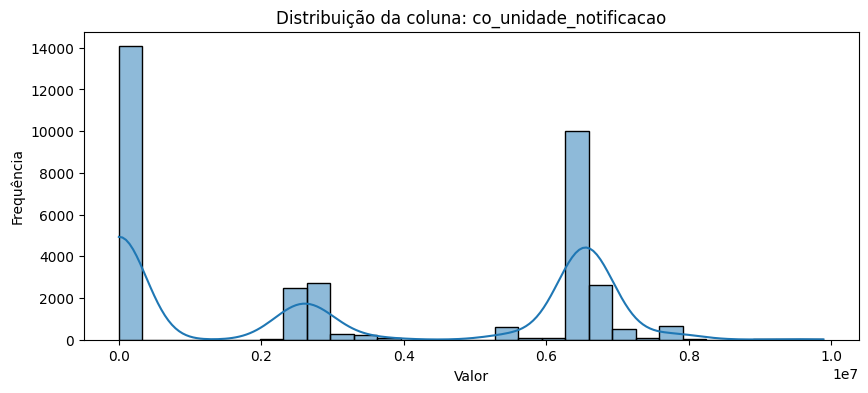

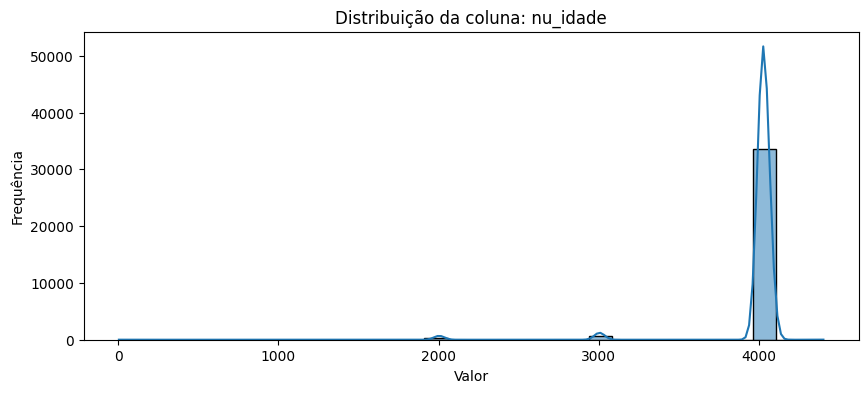

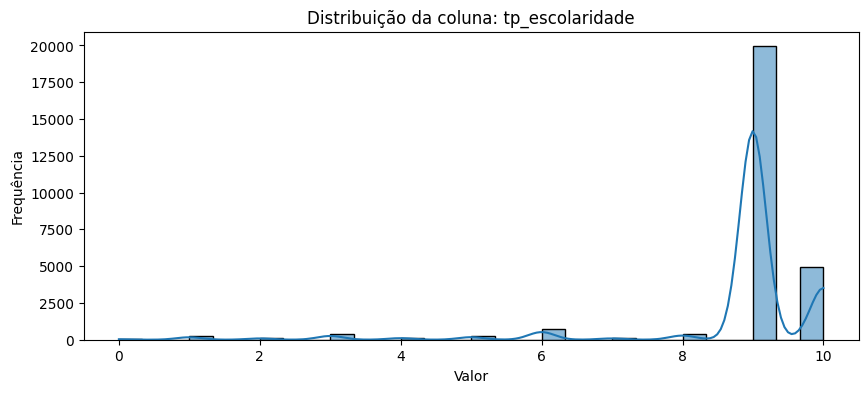

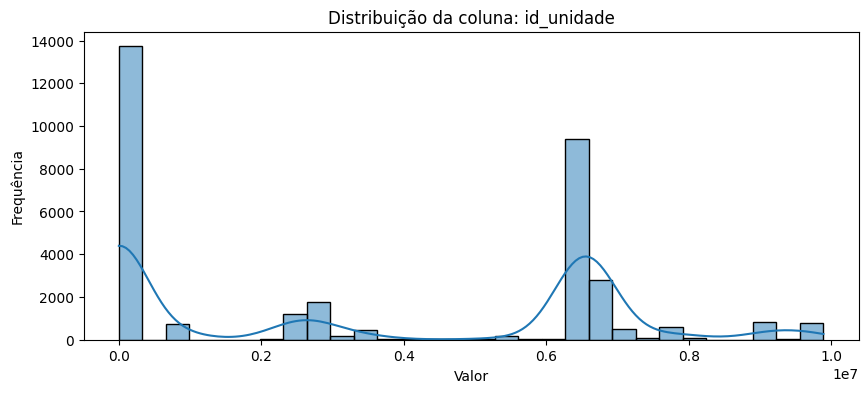

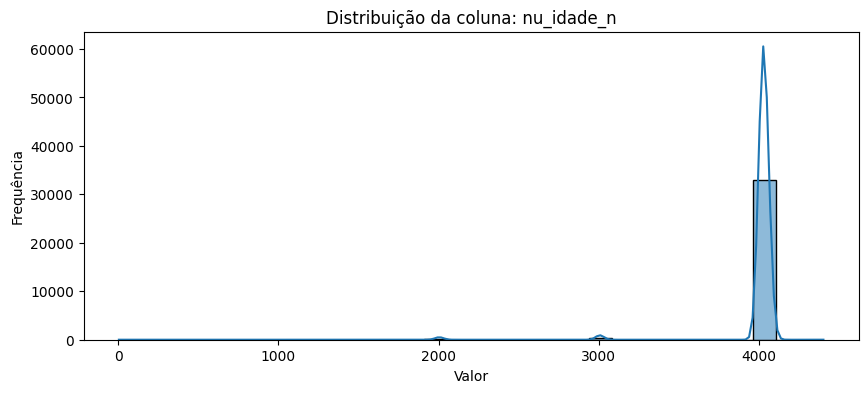

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vamos focar nas colunas que parecem ser idade numérica para plotar a distribuição
colunas_idade = [c for c in colunas_identificadas if 'idade' in c.lower()]

for col in colunas_idade:
    plt.figure(figsize=(10, 4))
    # Tenta converter para numérico para o gráfico, ignorando erros
    dados_plot = pd.to_numeric(df_original[col], errors='coerce').dropna()
    if not dados_plot.empty:
        sns.histplot(dados_plot, kde=True, bins=30)
        plt.title(f'Distribuição da coluna: {col}')
        plt.xlabel('Valor')
        plt.ylabel('Frequência')
        plt.show()
    else:
        print(f'A coluna {col} não possui dados numéricos válidos para histograma.')

# Limpeza

In [7]:
import pandas as pd

# Verificar nulos nas colunas de interesse
nulos_invest = df_original['dt_investigacao'].isna().sum()
nulos_nasc = df_original['dt_nascimento'].isna().sum()
total = len(df_original)

print(f"Total de registros: {total}")
print(f"Nulos em dt_investigacao: {nulos_invest} ({nulos_invest/total:.2%})")
print(f"Nulos em dt_nascimento: {nulos_nasc} ({nulos_nasc/total:.2%})")

Total de registros: 68140
Nulos em dt_investigacao: 34368 (50.44%)
Nulos em dt_nascimento: 34539 (50.69%)


### Nova Lógica de Idade com Fallback

Objetivo: Maximizar o preenchimento da coluna `idade` usando datas quando disponíveis e as colunas originais como backup.

In [8]:
def calcular_idade_com_fallback(df_input):
    df = df_input.copy()

    # 1. Preparar datas
    df['dt_investigacao'] = pd.to_datetime(df['dt_investigacao'], errors='coerce')
    df['dt_nascimento'] = pd.to_datetime(df['dt_nascimento'], errors='coerce')

    # 2. Cálculo primário (Datas)
    df['idade_calculada'] = (df['dt_investigacao'] - df['dt_nascimento']).dt.days / 365.25

    # 3. Preparar Fallback (Tratar nu_idade_n)
    def extrair_idade_sinan(valor):
        if pd.isna(valor): return pd.NA
        try:
            v = str(int(float(valor)))
            if len(v) == 4:
                prefixo = v[0]
                unidade = int(v[1:])
                if prefixo == '4': return unidade
                elif prefixo == '3': return unidade / 12
                elif prefixo == '2': return unidade / 365.25
        except (ValueError, TypeError):
            return pd.NA
        return pd.NA

    # Identificar qual coluna de backup está disponível
    col_original = None
    if 'nu_idade_n' in df.columns:
        col_original = 'nu_idade_n'
    elif 'nu_idade' in df.columns:
        col_original = 'nu_idade'

    # 4. Consolidar: Se houver coluna de backup, aplica extração
    if col_original:
        df['idade_fallback'] = df[col_original].apply(extrair_idade_sinan)
        df['idade'] = pd.to_numeric(df['idade_calculada'].fillna(df['idade_fallback']), errors='coerce')
    else:
        print("Aviso: Nenhuma coluna original de idade (nu_idade/nu_idade_n) encontrada. Usando apenas cálculo por datas.")
        df['idade'] = pd.to_numeric(df['idade_calculada'], errors='coerce')

    # 5. Limpeza Final
    cols_remover = ['nu_idade', 'nu_idade_n', 'idade_calculada', 'idade_fallback']
    df = df.drop(columns=[c for c in cols_remover if c in df.columns])

    return df

# Aplicando a lógica robusta
df_original = calcular_idade_com_fallback(df_original)

print(f"Total de nulos na nova coluna 'idade': {df_original['idade'].isna().sum()}")
display(df_original[['idade']].describe())

Total de nulos na nova coluna 'idade': 1821


,idade
count,66319.000000
mean,30.285404
std,19.798861
min,-0.802190
25%,13.793292
50%,28.000000
75%,43.718001
max,402.000000


In [9]:
# Verificar se todos os valores de idade são numéricos e estão entre 0 e 120

# 1. Tentar converter para numérico (caso haja algum resíduo) e remover nulos para a checagem
idades_validas = pd.to_numeric(df_original['idade'], errors='coerce').dropna()

# 2. Identificar valores fora do range
fora_do_range = idades_validas[(idades_validas < 0) | (idades_validas > 120)]

print(f"Total de registros analisados (não nulos): {len(idades_validas)}")
print(f"Registros com idade fora do intervalo [0, 120]: {len(fora_do_range)}")

if len(fora_do_range) > 0:
    print("\nExemplos de valores fora do intervalo:")
    display(df_original.loc[fora_do_range.index, ['dt_nascimento', 'dt_investigacao', 'idade']].head(10))
else:
    print("\nSucesso: Todos os valores numéricos estão dentro do intervalo de 0 a 120 anos.")

Total de registros analisados (não nulos): 66319
Registros com idade fora do intervalo [0, 120]: 46

Exemplos de valores fora do intervalo:


,dt_nascimento,dt_investigacao,idade
1260,2017-04-01,2017-02-10,-0.136893
1773,2017-07-01,2017-05-10,-0.142368
2155,2017-10-01,2017-06-11,-0.306639
2187,2017-10-01,2017-03-11,-0.558522
2334,2017-11-01,2017-01-12,-0.802190
4573,2018-09-01,2018-02-10,-0.555784
4784,2018-07-01,2018-05-11,-0.139630
4975,2018-07-01,2018-04-12,-0.219028
23409,NaT,NaT,402.000000
25407,NaT,NaT,400.000000


In [10]:
df = df_original.copy()

In [11]:
def padronizar_nulos(df):
    df = df.copy()
    nulos_comuns = ["", " ", "NA", "N/A", "nan", "None", "null", "NULL", "<NA>"]
    return df.replace(nulos_comuns, pd.NA)

def preservar_categoricas_como_string(df):
    df = df.copy()
    for c in df.columns:
        if PADRAO_CATEGORICAS.match(str(c)):
            df[c] = df[c].astype("string").str.strip()
    return df

def normalizar_datas(df):
    df = df.copy()
    date_cols = [c for c in df.columns if str(c).startswith("dt_")]
    relatorio = []

    for c in date_cols:
        s = df[c].astype("string").str.strip()
        s = s.replace("", pd.NA)

        # Assume YYYY-MM-DD format based on user input
        d = pd.to_datetime(s, errors="coerce", format="%Y-%m-%d")

        total = int(s.notna().sum())
        conv = int(d.notna().sum())
        nao_conv = int((s.notna() & d.isna()).sum())

        df[c] = d  # datetime real

    return df

df = padronizar_nulos(df)
df = preservar_categoricas_como_string(df)
df = normalizar_datas(df)

In [12]:
column_pairs = {
    'tp_sexo': 'cs_sexo',
    'tp_gestante': 'cs_gestant',
    'tp_raca_cor': 'cs_raca',
    'tp_escolaridade': 'cs_escol_n',
    'tp_zona_residencia': 'cs_zona',
    'tp_classificacao_final': 'classi_fin',
    'dt_nascimento': 'dt_nasc',
    'hipertensao': 'hipertensa',
    'conjutivite': 'conjuntvit'
}

for tp_col, cs_col in column_pairs.items():
    if tp_col in df.columns and cs_col in df.columns:
        # Fill NA in tp_col with values from cs_col
        df[tp_col] = df[tp_col].fillna(df[cs_col])
        # Drop the cs_col
        df = df.drop(columns=[cs_col])
        print(f"Consolidated '{cs_col}' into '{tp_col}' and dropped '{cs_col}'.")
    elif tp_col in df.columns:
        print(f"'{cs_col}' not found, keeping '{tp_col}'.")
    elif cs_col in df.columns:
        print(f"'{tp_col}' not found, keeping '{cs_col}'.")
    else:
        print(f"Neither '{tp_col}' nor '{cs_col}' found.")

print("\nHead of consolidated columns:")
display(df[column_pairs.keys()].head())

Consolidated 'cs_sexo' into 'tp_sexo' and dropped 'cs_sexo'.
Consolidated 'cs_gestant' into 'tp_gestante' and dropped 'cs_gestant'.
Consolidated 'cs_raca' into 'tp_raca_cor' and dropped 'cs_raca'.
Consolidated 'cs_escol_n' into 'tp_escolaridade' and dropped 'cs_escol_n'.


Consolidated 'cs_zona' into 'tp_zona_residencia' and dropped 'cs_zona'.
Consolidated 'classi_fin' into 'tp_classificacao_final' and dropped 'classi_fin'.
Consolidated 'dt_nasc' into 'dt_nascimento' and dropped 'dt_nasc'.
Consolidated 'hipertensa' into 'hipertensao' and dropped 'hipertensa'.


Consolidated 'conjuntvit' into 'conjutivite' and dropped 'conjuntvit'.

Head of consolidated columns:


,tp_sexo,tp_gestante,tp_raca_cor,tp_escolaridade,tp_zona_residencia,tp_classificacao_final,dt_nascimento,hipertensao,conjutivite
0,F,5,4,9,1,10,1957-10-01,2,2
1,F,9,9,9,9,10,1978-01-01,2,2
2,F,9,9,9,1,10,1944-10-01,2,2
3,F,2,9,9,1,5,1996-09-01,2,2
4,M,6,9,9,1,10,1964-05-01,2,2


In [13]:
# Total de colunas
total_columns = df.shape[1]
print(f"Total de colunas: {total_columns}")

# Total de instâncias (linhas)
total_rows = df.shape[0]
print(f"Total de instâncias: {total_rows}")


Total de colunas: 188
Total de instâncias: 68140


In [14]:
# Colunas com pelo menos 50% de nulos
null_percentages = df.isnull().sum() / len(df)
columns_with_50_percent_nulls = null_percentages[null_percentages >= 0.50]
print(f"\nNúmero de colunas com pelo menos 50% de nulos: {len(columns_with_50_percent_nulls)}")


Número de colunas com pelo menos 50% de nulos: 139


In [15]:
# Colunas com pelo menos 100% de nulos
columns_with_all_nulls = null_percentages[null_percentages >= 1]
print(f"\nNúmero de colunas com todos nulos: {len(columns_with_all_nulls)}")
print("Colunas com todos nulos:")
display(columns_with_all_nulls.sort_values(ascending=False))


Número de colunas com todos nulos: 17
Colunas com todos nulos:


co_logradouro_residencia    1.0
plasmatico                  1.0
nu_lote_i                   1.0
doenca_tra                  1.0
dt_chik_s2                  1.0
id_logrado                  1.0
con_fhd                     1.0
evidencia                   1.0
laco_n                      1.0
dt_chil_s2                  1.0
sangram                     1.0
hematura                    1.0
petequias                   1.0
metro                       1.0
gengivo                     1.0
epistaxe                    1.0
conf_fhd                    1.0
dtype: float64

In [16]:
# Filtrar colunas que não são 100% nulas
not_100_percent_null_columns = null_percentages[null_percentages < 1]

# Top 10 colunas com maior quantidade de nulos, excluindo as 100% nulas
print("\nTop 10 colunas com maior quantidade de nulos (excluindo as 100% nulas):")
display(df[not_100_percent_null_columns.index].isnull().sum().sort_values(ascending=False).head(10))



Top 10 colunas com maior quantidade de nulos (excluindo as 100% nulas):


plaq_menor     68138
mani_hemor     68138
complica       68138
tp_sorotipo    68113
dt_grav        68093
grav_ast       68091
grav_ench      68091
grav_consc     68091
grav_mioc      68091
grav_conv      68091
dtype: int64

In [17]:
# 5. Verificar duplicatas
duplicates_count = df.duplicated().sum()
print(f"\nNúmero de linhas duplicadas: {duplicates_count}")

df.drop_duplicates(inplace=True)


Número de linhas duplicadas: 9


In [18]:
threshold = 0.90 # 90% null values

# Calculate the percentage of null values for each column
null_percentages = df.isnull().sum() / len(df)

# Identify columns to drop
cols_to_drop_high_nulls = null_percentages[null_percentages > threshold].index.tolist()

print(f"Columns to drop due to >{threshold*100}% null values: {cols_to_drop_high_nulls}")

if cols_to_drop_high_nulls:
    df = df.drop(columns=cols_to_drop_high_nulls)
    print(f"Dropped {len(cols_to_drop_high_nulls)} columns. New DataFrame shape: {df.shape}")
else:
    print("No columns found with >90% null values.")

Columns to drop due to >90.0% null values: ['co_logradouro_residencia', 'co_cbo_ocupacao', 'dt_chil_s1', 'dt_chil_s2', 'dt_prnt', 'res_chiks1', 'res_chiks2', 'resul_prnt', 'dt_coleta_exame', 'dt_coleta_ns1', 'dt_coleta_isolamento', 'dt_coleta_rtpcr', 'tp_sorotipo', 'dt_internacao', 'co_uf_hospital', 'co_municipio_hospital', 'co_distrito_infeccao', 'co_bairro_infeccao', 'no_bairro_infeccao', 'st_doenca_trabalho', 'clinc_chik', 'dt_obito', 'alrm_hipot', 'alrm_plaq', 'alrm_vom', 'alrm_sang', 'alrm_hemat', 'alrm_abdom', 'alrm_letar', 'alrm_hepat', 'alrm_liq', 'dt_alrm', 'epistaxe', 'gengivo', 'metro', 'petequias', 'hematura', 'sangram', 'laco_n', 'plasmatico', 'evidencia', 'plaq_menor', 'hospital', 'ddd_hospital', 'tel_hospital', 'con_fhd', 'id_logrado', 'id_ocupa_n', 'dt_chik_s1', 'dt_chik_s2', 'dt_soro', 'resul_soro', 'dt_ns1', 'resul_ns1', 'dt_viral', 'resul_vi_n', 'dt_pcr', 'sorotipo', 'histopa_n', 'imunoh_n', 'dt_interna', 'uf', 'municipio', 'ddd_hosp', 'tel_hosp', 'tpautocto', 'coufi

In [19]:
cols_to_drop_high_similarity = []
num_rows = len(df)

for col in df.columns:
    if num_rows > 0:
        # Calculate the count of each unique value
        value_counts = df[col].value_counts(dropna=False)
        if not value_counts.empty:
            # Get the count of the most frequent value
            most_frequent_value_count = value_counts.iloc[0]

            # Calculate the percentage of the most frequent value
            percentage_most_frequent = (most_frequent_value_count / num_rows) * 100

            if percentage_most_frequent >= 90:
                cols_to_drop_high_similarity.append(col)

print(f"Columns to drop due to >=90% identical values: {cols_to_drop_high_similarity}")

if cols_to_drop_high_similarity:
    df = df.drop(columns=cols_to_drop_high_similarity)
    print(f"Dropped {len(cols_to_drop_high_similarity)} columns. New DataFrame shape: {df.shape}")
else:
    print("No columns found with >=90% identical values.")

Columns to drop due to >=90% identical values: []
No columns found with >=90% identical values.


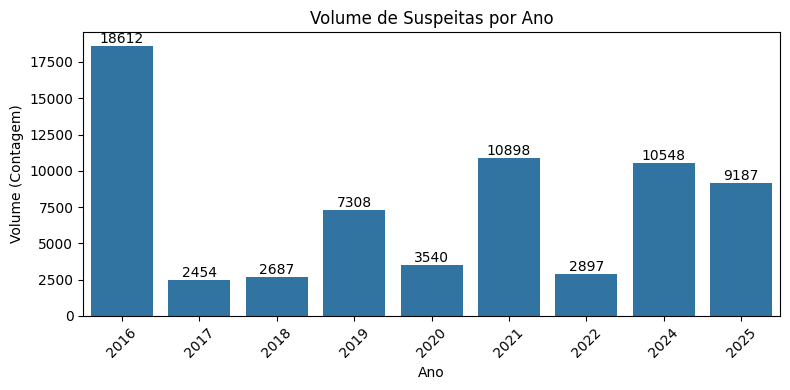

In [20]:
plt.figure(figsize=(8, 4))
counts = df['__ano_recurso'].value_counts().sort_index()
ax = sns.barplot(x=counts.index, y=counts.values)
plt.title('Volume de Suspeitas por Ano')
plt.xlabel('Ano')
plt.ylabel('Volume (Contagem)')
plt.xticks(rotation=45)

# Adiciona labels com o volume nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

In [21]:
df['tp_classificacao_final'].value_counts()

tp_classificacao_final
10    35978
5     28885
8      2558
11      368
12       31
1         3
2         2
Name: count, dtype: Int64

In [22]:
# Mapeamento baseado na gravidade clínica
mapeamento = {
    '1': 'Comum',              # Dengue Clássico
    '10': 'Comum',             # Dengue (Classificação nova)
    '11': 'Alerta/Grave',  # Dengue com sinais de alarme
    '12': 'Alerta/Grave',  # Dengue grave
    '2': 'Alerta/Grave',   # Dengue com complicações (Antiga)
    '3': 'Alerta/Grave',   # Febre Hemorrágica (Antiga)
    '4': 'Alerta/Grave',   # Síndrome do Choque (Antiga)
    '5': 'Descartado'      # Não é dengue
}

# 1. Remover a classe 8 (Inconclusivo) antes de mapear
df = df[df['tp_classificacao_final'] != 8].copy()

# 2. Criar a nova coluna agrupada
df['classificacao_agrupada'] = df['tp_classificacao_final'].map(mapeamento)

# Verificar o novo balanceamento
print(df['classificacao_agrupada'].value_counts())

classificacao_agrupada
Comum           35981
Descartado      28885
Alerta/Grave      401
Name: count, dtype: int64


In [23]:
df['semana_num'] = df['ds_semana_notificacao'].astype(str).str.strip()
df['semana_num'] = df['semana_num'].str.extract(r'(\d+)')

# Convertendo para string, pegando os 2 últimos caracteres e transformando em int
df['semana_num'] = df['semana_num'].str[-2:]
df['semana_num'] = pd.to_numeric(df['semana_num'], errors='coerce')
df['semana_num'] = df['semana_num'].fillna(-1).astype(int)

print(df['semana_num'].unique())

[ 2  3  1 15 12  6 11 13  8  5  4 14 20 19 17  7 23 18 42 10  9 36 37 35
 34 16 39 40 21 27 26 22 24 25 38 32 41 29 28 30 31 33 45 44 43 47 46 50
 49 48 51 52 -1 53]


In [24]:
# Lista de colunas para remover categorizadas
vazamento_e_resposta = [
    'criterio', 'evolucao', 'hospitaliz', 'st_ocorreu_hospitalizacao',
    'tp_result_exame', 'tp_result_ns1', 'tp_result_isolamento', 'tp_criterio_confirmacao',
    'tp_result_rtpcr', 'tp_result_histopatologia', 'tp_classificacao_final',
    'tp_result_imunohistoquimica', 'resul_pcr_', 'tp_evolucao_caso', 'tp_result_imunohistoquimica'
]

administrativas_e_ids = [
    'nu_notific', 'tp_not', 'id_agravo', 'tp_notificacao', 'nu_ano', 'nu_idade_n'
    'notificacao_ano', 'co_cid', 'co_unidade_notificacao', 'id_unidade',
    'id_regiona', 'id_regional', 'co_uf_notificacao', 'sg_uf_not', 'notificacao_ano',
    'co_pais_residencia', 'id_pais', 'co_pais_infeccao', '__arquivo_origem',
    '__ano_recurso', 'nu_notificacao', 'ds_semana_notificacao', 'ds_semana_sintoma',
    'sem_pri', 'sem_not', 'tp_autoctone_residencia', 'nu_idade', 'id_mn_resi', 'nu_idade_n'

]

endereco_especifico = [
    'no_bairro_residencia', 'nm_bairro', 'id_bairro', 'co_bairro_residencia',
    'nome_logradouro_residencia', 'nm_logrado', 'nu_cep_residencia', 'nu_cep',
    'co_distrito_residencia', 'id_distrit', 'co_municipio_notificacao', 'co_uf_residencia',
    'id_municip', 'co_regional_residencia', 'id_rg_resi', 'tp_zona_residencia', 'co_municipio_infeccao',
    'co_uf_infeccao', 'co_municipio_residencia', 'sg_uf'
]

colunas_de_data = [c for c in df.columns if str(c).startswith("dt_")]

# Lista consolidada de remoção
colunas_para_dropar = vazamento_e_resposta + administrativas_e_ids + endereco_especifico + colunas_de_data

# Executando o drop (ignora se a coluna não existir para evitar erros)
df = df.drop(columns=[c for c in colunas_para_dropar if c in df.columns])

print(f"Colunas restantes: {len(df.columns)}")
print(df.columns.tolist())

Colunas restantes: 28
['tp_sexo', 'tp_gestante', 'tp_raca_cor', 'tp_escolaridade', 'febre', 'mialgia', 'cefaleia', 'exantema', 'vomito', 'nausea', 'dor_costas', 'conjutivite', 'artrite', 'artralgia', 'petequia_n', 'leucopenia', 'laco', 'dor_retro', 'diabetes', 'hematolog', 'hepatopat', 'renal', 'hipertensao', 'acido_pept', 'auto_imune', 'idade', 'classificacao_agrupada', 'semana_num']


# EDA

In [25]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def check_leakage(X, y):
    X_encoded = X.copy()
    le = LabelEncoder()

    # Pre-processamento: Transformar tudo em string e depois em números
    for col in X_encoded.columns:
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

    # O y também precisa ser numérico para o mutual_info
    y_encoded = le.fit_transform(y.astype(str))

    # Agora rodamos o cálculo
    mi = mutual_info_classif(X_encoded, y_encoded, discrete_features=True)
    mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

    return mi_series

y = df['classificacao_agrupada']
X = df.drop(columns=['classificacao_agrupada'])

mi_series = check_leakage(X, y)

print("Top Variáveis com maior relação com o Alvo (MI Score):")
print(mi_series.head(15))

Top Variáveis com maior relação com o Alvo (MI Score):
idade          0.292377
febre          0.049610
exantema       0.040890
mialgia        0.039049
cefaleia       0.038145
artralgia      0.037882
vomito         0.035627
dor_retro      0.034880
leucopenia     0.034855
conjutivite    0.034725
petequia_n     0.034690
dor_costas     0.034608
nausea         0.034573
artrite        0.034066
hipertensao    0.033942
dtype: float64


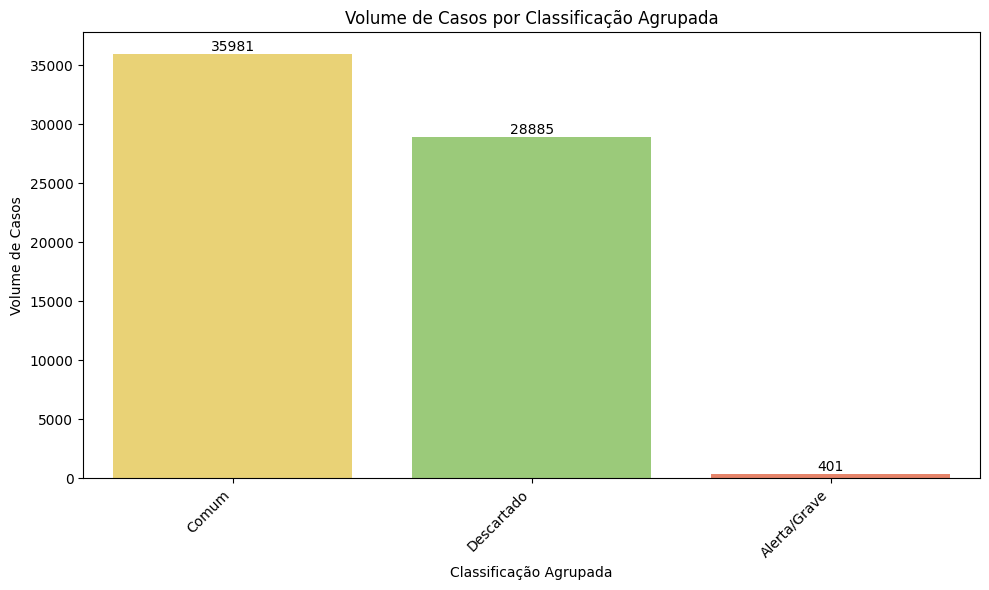

In [26]:
# Calcular o volume de cada categoria em 'classificacao_agrupada'
volume_por_classificacao = df['classificacao_agrupada'].value_counts().reset_index(name='volume')
volume_por_classificacao.columns = ['classificacao_agrupada', 'volume']

# Definir o mapeamento de cores
palette_cores = {
    'Descartado': '#99d76d',
    'Comum': '#fcde63',
    'Alerta/Grave': '#f97856'
}

# Gerar o gráfico de barras com as novas cores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='classificacao_agrupada', y='volume', data=volume_por_classificacao, palette=palette_cores)
plt.title('Volume de Casos por Classificação Agrupada')
plt.xlabel('Classificação Agrupada')
plt.ylabel('Volume de Casos')
plt.xticks(rotation=45, ha='right')

# Adicionar labels com o volume nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

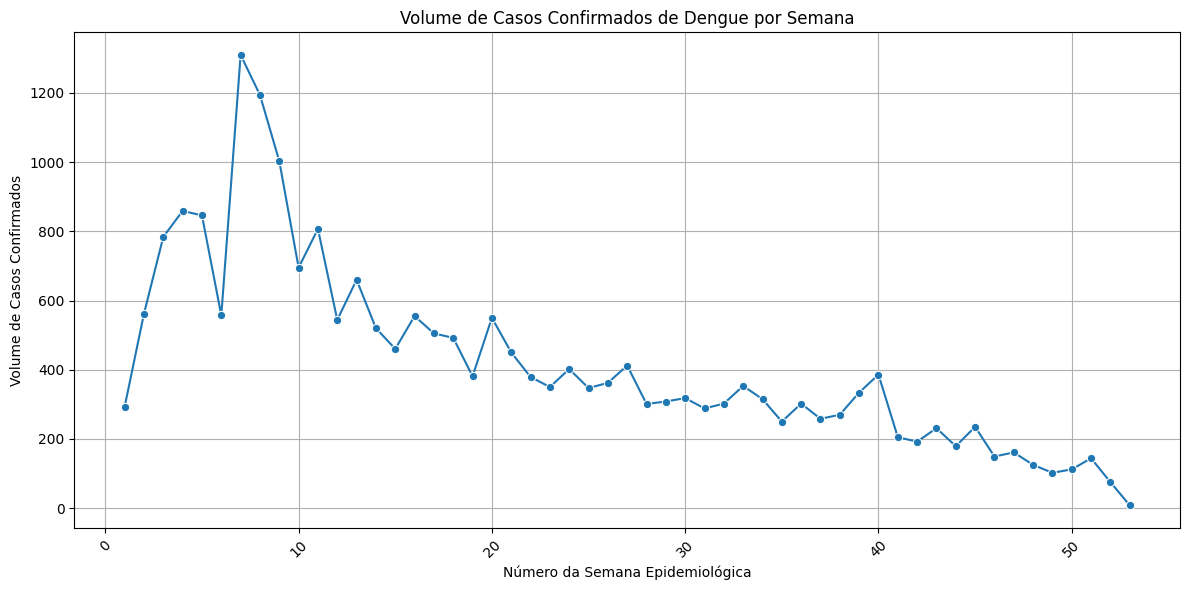

In [27]:
# Filtrar casos que não são 'Descartado'
confirmed_cases_df = df[df['classificacao_agrupada'] != 'Descartado'].copy()

# Agrupar por semana e contar o volume de casos confirmados
volume_por_semana = confirmed_cases_df.groupby('semana_num').size().reset_index(name='volume_casos_confirmados')

# Remover semanas com valor -1, que provavelmente representam dados ausentes ou inválidos
volume_por_semana = volume_por_semana[volume_por_semana['semana_num'] != -1]

# Ordenar por semana_num para o gráfico de linha
volume_por_semana = volume_por_semana.sort_values(by='semana_num')

# Gerar o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(data=volume_por_semana, x='semana_num', y='volume_casos_confirmados', marker='o')
plt.title('Volume de Casos Confirmados de Dengue por Semana')
plt.xlabel('Número da Semana Epidemiológica')
plt.ylabel('Volume de Casos Confirmados')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

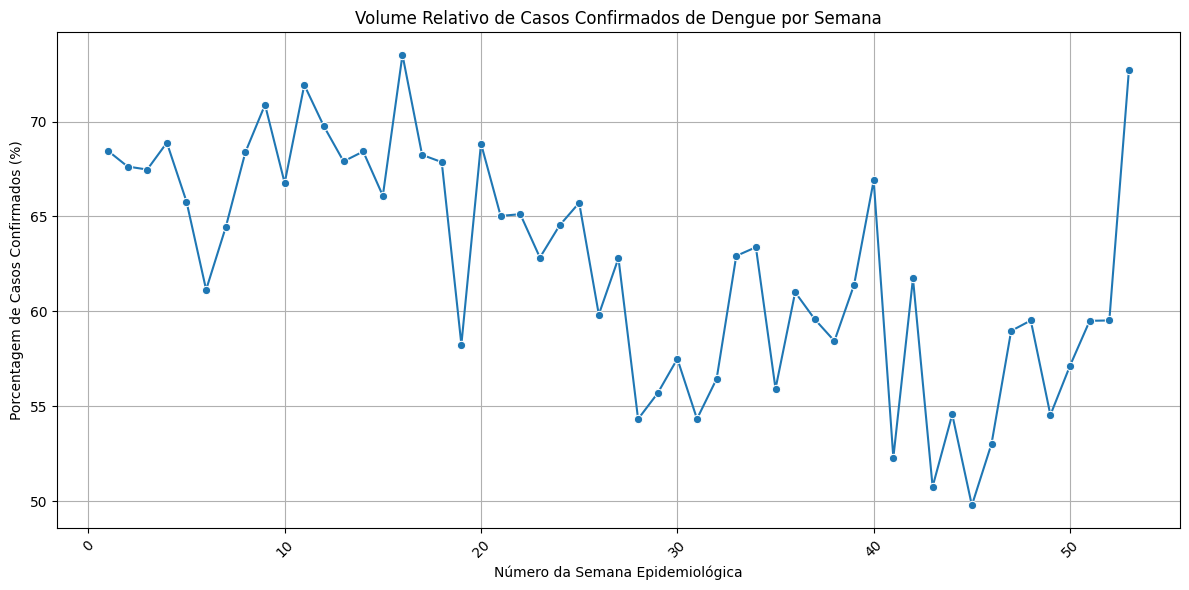

In [28]:
# 1. Calcular o volume total de casos por semana (incluindo descartados e inconclusivos)
total_casos_por_semana = df.groupby('semana_num').size().reset_index(name='total_casos')

# 2. Calcular o volume de casos confirmados por semana (já temos 'confirmed_cases_df')
volume_casos_confirmados_por_semana = confirmed_cases_df.groupby('semana_num').size().reset_index(name='volume_casos_confirmados')

# 3. Juntar os dois DataFrames
casos_por_semana = pd.merge(
    total_casos_por_semana,
    volume_casos_confirmados_por_semana,
    on='semana_num',
    how='left'
)

# Preencher NaN com 0 para semanas sem casos confirmados e remover semanas inválidas
casos_por_semana['volume_casos_confirmados'] = casos_por_semana['volume_casos_confirmados'].fillna(0)
casos_por_semana = casos_por_semana[casos_por_semana['semana_num'] != -1]

# 4. Calcular o volume relativo (porcentagem de casos confirmados)
casos_por_semana['volume_relativo_confirmado'] = (casos_por_semana['volume_casos_confirmados'] / casos_por_semana['total_casos']) * 100

# 5. Ordenar por semana_num para o gráfico de linha
casos_por_semana = casos_por_semana.sort_values(by='semana_num')

# 6. Gerar o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(data=casos_por_semana, x='semana_num', y='volume_relativo_confirmado', marker='o')
plt.title('Volume Relativo de Casos Confirmados de Dengue por Semana')
plt.xlabel('Número da Semana Epidemiológica')
plt.ylabel('Porcentagem de Casos Confirmados (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
# Cria um novo DataFrame sem as linhas com NaN na coluna específica
df = df.dropna(subset=['classificacao_agrupada'])

In [30]:
df.classificacao_agrupada.isna().sum()

np.int64(0)

In [31]:
# Mapeamento personalizado para tp_sexo
sexo_mapping = {
    'F': 1,
    'M': 2,
    'I': 0,
    pd.NA: 0
}

# Mapeamento personalizado para 'classificacao_agrupada'
mapeamento_classificacao = {
    'Descartado': 0,
    'Comum': 1,
    'Alerta/Grave': 2
}

df['classificacao_agrupada'] = df['classificacao_agrupada'].map(mapeamento_classificacao).astype(int)
df['tp_sexo'] = df['tp_sexo'].map(sexo_mapping).fillna(0).astype(int)

# Converter as outras colunas de string para numérico e depois para int
for col in df.columns:
    if df[col].dtype == 'string' and col != 'classificacao_agrupada':
        # Converter para numérico, tratando erros (e.g., '1' e '1.0' são tratados como números)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Preencher NaNs com 0 antes de converter para int
        df[col] = df[col].fillna(0).astype(int)

print("Tipos de dados atualizados:")
df.info()

# Preencher NaN remanescentes (ex: idade sem data de nascimento) com 0
df = df.fillna(0)

Tipos de dados atualizados:
<class 'pandas.core.frame.DataFrame'>
Index: 65267 entries, 0 to 68139
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tp_sexo                 65267 non-null  int64  
 1   tp_gestante             65267 non-null  int64  
 2   tp_raca_cor             65267 non-null  int64  
 3   tp_escolaridade         65267 non-null  int64  
 4   febre                   65267 non-null  int64  
 5   mialgia                 65267 non-null  int64  
 6   cefaleia                65267 non-null  int64  
 7   exantema                65267 non-null  int64  
 8   vomito                  65267 non-null  int64  
 9   nausea                  65267 non-null  int64  
 10  dor_costas              65267 non-null  int64  
 11  conjutivite             65267 non-null  int64  
 12  artrite                 65267 non-null  int64  
 13  artralgia               65267 non-null  int64  
 14  petequia_n     

### Binarização de Features com 3 níveis (0, 1, 2)

Transformando colunas que possuem especificamente os valores 0, 1 e 2 para um formato binário, onde:
*   0 e 1 tornam-se **0**
*   2 torna-se **1**

In [32]:
cols_to_binarize = []
for col in df.columns:
    # Ignorar a coluna alvo
    if col == 'classificacao_agrupada':
        continue

    unique_vals = set(df[col].unique())
    # Verifica se a coluna contém exatamente os valores 0, 1 e 2
    if unique_vals == {0, 1, 2}:
        cols_to_binarize.append(col)

print(f"Colunas identificadas para binarização: {cols_to_binarize}")

# Aplicar a transformação: 0, 1 -> 0 | 2 -> 1
for col in cols_to_binarize:
    df[col] = df[col].replace({0: 0, 1: 0, 2: 1})

print("\nVerificação dos novos valores únicos nas colunas transformadas:")
for col in cols_to_binarize:
    print(f"{col}: {df[col].unique()}")

display(df[cols_to_binarize].head())

Colunas identificadas para binarização: ['tp_sexo', 'febre', 'mialgia', 'cefaleia', 'exantema', 'vomito', 'nausea', 'dor_costas', 'conjutivite', 'artrite', 'artralgia', 'petequia_n', 'leucopenia', 'laco', 'dor_retro', 'diabetes', 'hematolog', 'hepatopat', 'renal', 'hipertensao', 'acido_pept', 'auto_imune']

Verificação dos novos valores únicos nas colunas transformadas:
tp_sexo: [0 1]
febre: [0 1]
mialgia: [0 1]
cefaleia: [0 1]
exantema: [1 0]
vomito: [1 0]
nausea: [1 0]
dor_costas: [1 0]
conjutivite: [1 0]
artrite: [1 0]
artralgia: [0 1]
petequia_n: [1 0]
leucopenia: [1 0]
laco: [1 0]
dor_retro: [1 0]
diabetes: [1 0]
hematolog: [1 0]
hepatopat: [1 0]
renal: [1 0]
hipertensao: [1 0]
acido_pept: [1 0]
auto_imune: [1 0]


,tp_sexo,febre,mialgia,cefaleia,exantema,vomito,nausea,dor_costas,conjutivite,artrite,...,leucopenia,laco,dor_retro,diabetes,hematolog,hepatopat,renal,hipertensao,acido_pept,auto_imune
0,0,0,0,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
1,0,0,0,0,0,0,0,1,1,1,...,1,1,0,1,1,1,1,1,1,1
2,0,0,0,0,1,0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3,0,0,0,0,0,1,1,1,1,1,...,1,1,0,1,1,1,1,1,1,1
4,1,0,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


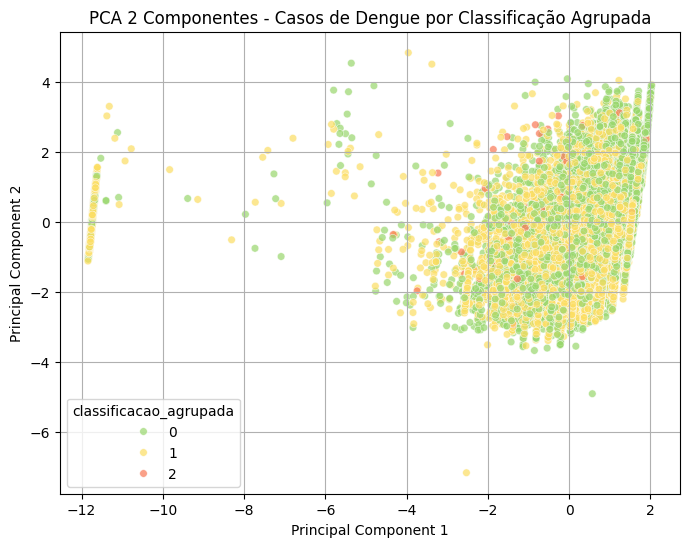

In [33]:
# --- PCA para redução de dimensionalidade e visualização ---

palette_cores = {
    0: '#99d76d',
    1: '#fcde63',
    2: '#f97856'
}

# Separar features (X) e target (y)
y_pca = df['classificacao_agrupada']
X_pca = df.drop(columns=['classificacao_agrupada'])

# Identificar colunas categóricas e numéricas
categorical_cols_pca = X_pca.select_dtypes(include=['object', 'category', 'bool']).columns
numerical_cols_pca = [col for col in X_pca.columns if col not in categorical_cols_pca]

# Preencher valores nulos para evitar erros no LabelEncoder e StandardScaler
# Para categóricas: preencher com 'Missing' para que o LabelEncoder possa criar uma categoria para isso
for col in categorical_cols_pca:
    if col in X_pca.columns:
        X_pca[col] = X_pca[col].fillna('Missing').astype(str)

# Para numéricas: preencher com 0 (ou outra estratégia como a média/mediana)
for col in numerical_cols_pca:
    if col in X_pca.columns:
        X_pca[col] = pd.to_numeric(X_pca[col], errors='coerce').fillna(0)

# Aplicar Label Encoding para colunas categóricas
le_pca = LabelEncoder()
for col in categorical_cols_pca:
    if col in X_pca.columns:
        X_pca[col] = le_pca.fit_transform(X_pca[col])

# Escalar as features
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca)

# Aplicar PCA
pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_transformed = pca_model.fit_transform(X_scaled_pca)

# Criar um DataFrame para plotagem
df_pca = pd.DataFrame(
    data=X_pca_transformed,
    columns=['Principal Component 1', 'Principal Component 2']
)
df_pca['classificacao_agrupada'] = y_pca.reset_index(drop=True)

# Plotar os resultados do PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='classificacao_agrupada',
    palette=palette_cores,
    data=df_pca,
    s=30,  # Tamanho dos pontos
    alpha=0.7 # Transparência dos pontos
)
plt.title('PCA 2 Componentes - Casos de Dengue por Classificação Agrupada')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

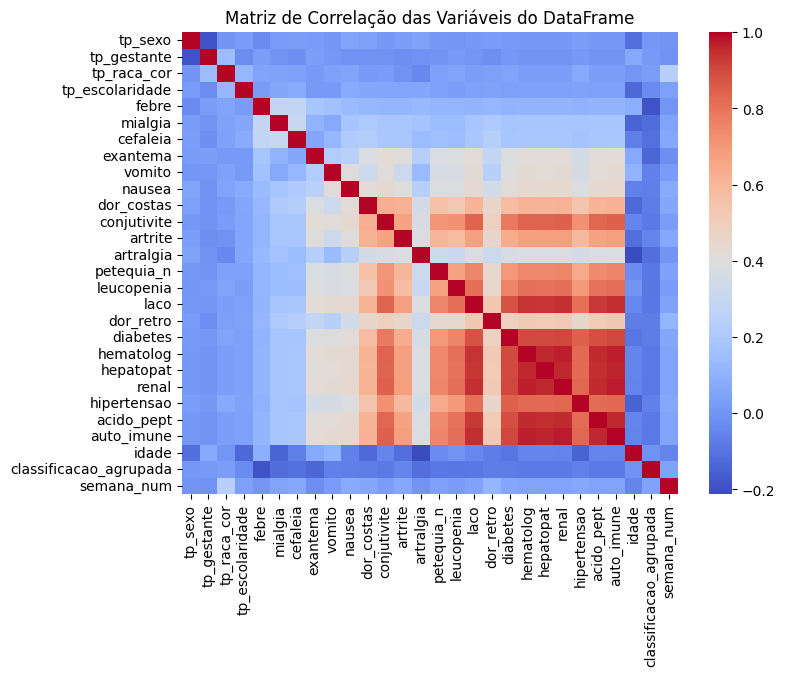

In [34]:
# Calculate the correlation matrix
correlation_matrix = df.select_dtypes(include='number').fillna(0).corr()

# Plot the heatmap
plt.figure(figsize=(8, 6)) # Adjust size for readability
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis do DataFrame')
plt.show()

### Histogramas para Variáveis Numéricas

### Gráficos de Barras para Variáveis Categóricas

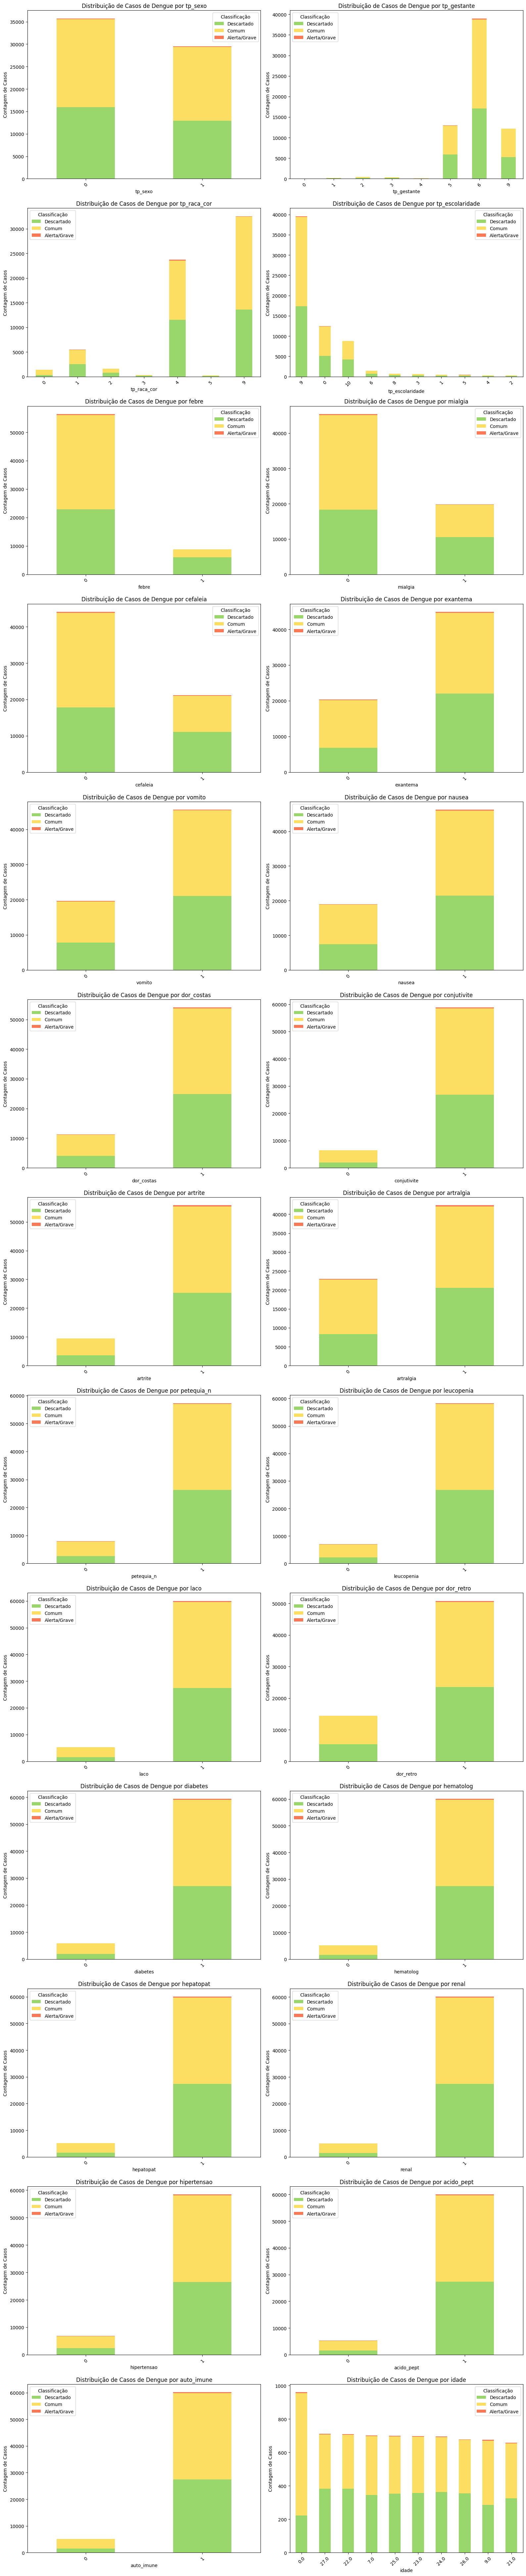

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar colunas que são de natureza categórica (excluindo a coluna alvo e 'semana_num')
categorical_like_cols = [col for col in df.columns if col not in ['classificacao_agrupada', 'semana_num']]

# Calcular o número de linhas necessário para 2 gráficos por linha
num_cols_to_plot = len(categorical_like_cols)
num_rows = (num_cols_to_plot + 1) // 2  # Arredonda para cima para garantir todas as colunas

# Criar a figura e os subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(16, num_rows * 6))
axes = axes.flatten() # Achata a matriz de eixos para facilitar a iteração

# Criar gráficos de barras empilhadas para as variáveis que são tratadas como categóricas
for i, col in enumerate(categorical_like_cols):
    ax = axes[i]

    # Calcular a contagem de cada tipo de classificação agrupada por cada categoria da coluna
    # Usamos pd.crosstab para uma contagem mais fácil para gráficos empilhados
    crosstab_df = pd.crosstab(df[col], df['classificacao_agrupada'])

    # Se houver muitas categorias, pegamos as top 10 ou um número razoável
    if len(crosstab_df) > 10:
        # Para pegar as top N, precisamos decidir com base em qual soma, por exemplo, a soma total de casos
        top_categories = crosstab_df.sum(axis=1).nlargest(10).index
        crosstab_df = crosstab_df.loc[top_categories]

    # Plotar o gráfico de barras empilhadas
    crosstab_df.plot(kind='bar', stacked=True, ax=ax, color=[palette_cores[j] for j in sorted(palette_cores.keys())])

    # Configurar o título e rótulos
    ax.set_title(f'Distribuição de Casos de Dengue por {col}', fontsize=12)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Contagem de Casos', fontsize=10)
    ax.tick_params(axis='x', rotation=45)

    # Adicionar uma legenda
    legend_labels = {0: 'Descartado', 1: 'Comum', 2: 'Alerta/Grave'}
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [legend_labels[int(label)] for label in labels], title='Classificação')

# Remover subplots vazios, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Modelo - Treino e Validação

### Experimento 0: Baseline

In [36]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

# Separar features (X) e target (y)
X = df.drop(columns=['classificacao_agrupada'])
y = df['classificacao_agrupada']

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Shape do X_train: {X_train.shape}")
print(f"Shape do X_test: {X_test.shape}")
print(f"Shape do y_train: {y_train.shape}")
print(f"Shape do y_test: {y_test.shape}")

# Treinar um modelo LightGBM
# a variável alvo é multi-classe (0, 1, 2)
# 'objective': 'multiclass' e 'num_class' são apropriados
model = LGBMClassifier(objective='multiclass', num_class=len(y.unique()), random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
print("\n--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

Shape do X_train: (52213, 27)
Shape do X_test: (13054, 27)
Shape do y_train: (52213,)
Shape do y_test: (13054,)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003238 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 52213, number of used features: 27
[LightGBM] [Info] Start training from score -0.815153
[LightGBM] [Info] Start training from score -0.595512
[LightGBM] [Info] Start training from score -5.091646



--- Relatório de Classificação ---
              precision    recall  f1-score   support

  Descartado       0.64      0.53      0.58      5777
       Comum       0.67      0.76      0.71      7197
Alerta/Grave       0.09      0.01      0.02        80

    accuracy                           0.66     13054
   macro avg       0.47      0.44      0.44     13054
weighted avg       0.65      0.66      0.65     13054



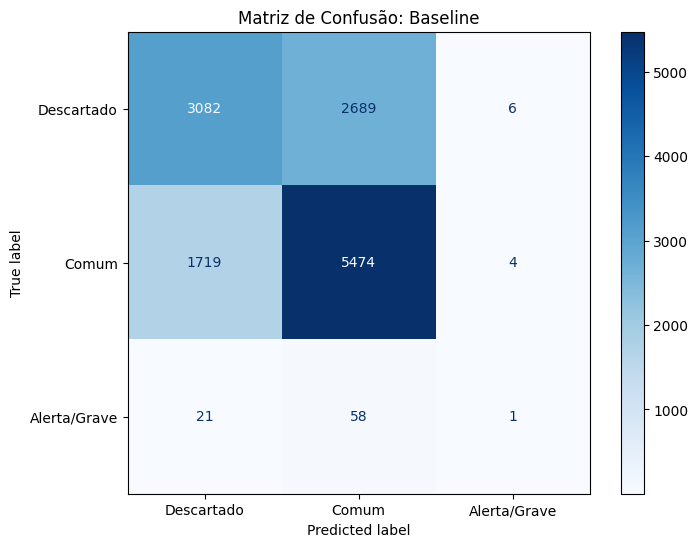

  [MLflow] 'Baseline' — f1_macro=0.438  recall_alerta_grave=0.013


'ef2c05cdb625402c916d258de5863e09'

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matriz de Confusão - Baseline
cm_baseline = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusão: Baseline')
plt.show()
log_exp('Baseline', 'LightGBM', 'Nenhum', y_test, y_pred, fig,
    params={'random_state': RANDOM_STATE, 'objective': 'multiclass'},
    model=model)

### Experimento 1: SMOTE (Synthetic Minority Over-sampling Technique)

Neste experimento, utilizaremos o SMOTE para gerar amostras sintéticas da classe minoritária ('Alerta/Grave') no conjunto de treinamento. Isso ajuda o modelo a 'aprender' melhor sobre essa classe, que antes estava sub-representada.

In [38]:
from imblearn.over_sampling import SMOTE

print("--- Experimento com SMOTE ---")

# Aplicar SMOTE ao conjunto de treinamento
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Shape do X_train após SMOTE: {X_train_smote.shape}")
print(f"Distribuição da classe alvo após SMOTE:\n{y_train_smote.value_counts()}")

# Treinar um modelo LightGBM com os dados balanceados por SMOTE
model_smote = LGBMClassifier(objective='multiclass', num_class=len(y.unique()), random_state=RANDOM_STATE)
model_smote.fit(X_train_smote, y_train_smote)

# Fazer previsões no conjunto de teste original
y_pred_smote = model_smote.predict(X_test)

# Avaliar o modelo
print("\n--- Relatório de Classificação (SMOTE) ---")
print(classification_report(y_test, y_pred_smote, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

--- Experimento com SMOTE ---


Shape do X_train após SMOTE: (86352, 27)
Distribuição da classe alvo após SMOTE:
classificacao_agrupada
0    28784
1    28784
2    28784
Name: count, dtype: int64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005133 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 86352, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612



--- Relatório de Classificação (SMOTE) ---
              precision    recall  f1-score   support

  Descartado       0.59      0.65      0.61      5777
       Comum       0.70      0.59      0.64      7197
Alerta/Grave       0.03      0.21      0.05        80

    accuracy                           0.61     13054
   macro avg       0.44      0.48      0.43     13054
weighted avg       0.64      0.61      0.62     13054



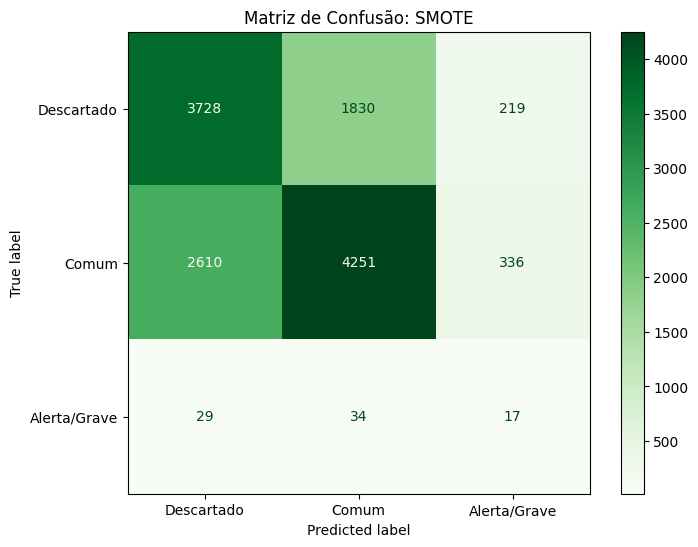

  [MLflow] 'SMOTE' — f1_macro=0.435  recall_alerta_grave=0.212


'8e3c55707327470f8a6a3db34cd1a19a'

In [39]:
# Matriz de Confusão - SMOTE
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Greens', ax=ax)
plt.title('Matriz de Confusão: SMOTE')
plt.show()
log_exp('SMOTE', 'LightGBM', 'SMOTE', y_test, y_pred_smote, fig,
    params={'random_state': RANDOM_STATE},
    model=model_smote)

### Experimento 2: Ajuste de Pesos de Classe (Class Weights)

Neste experimento, o LightGBM será treinado com pesos de classe ajustados. Isso fará com que o modelo penalize mais os erros cometidos na classe minoritária ('Alerta/Grave'), incentivando-o a dar mais atenção a ela sem a necessidade de gerar novas amostras.

In [40]:
from sklearn.utils import class_weight

print("--- Experimento com Pesos de Classe ---")

# Calcular os pesos de classe
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
# Convert class_weights to a dictionary for LightGBM
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

print(f"Pesos de Classe Calculados: {class_weights_dict}")

# Treinar um modelo LightGBM com pesos de classe
model_cw = LGBMClassifier(objective='multiclass', num_class=len(y.unique()), random_state=RANDOM_STATE, class_weight=class_weights_dict)
model_cw.fit(X_train, y_train)

# Fazer previsões no conjunto de teste original
y_pred_cw = model_cw.predict(X_test)

# Avaliar o modelo
print("\n--- Relatório de Classificação (Class Weights) ---")
print(classification_report(y_test, y_pred_cw, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

--- Experimento com Pesos de Classe ---
Pesos de Classe Calculados: {0: np.float64(0.7531735041255554), 1: np.float64(0.6046530479896238), 2: np.float64(54.219106957424714)}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 52213, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612



--- Relatório de Classificação (Class Weights) ---
              precision    recall  f1-score   support

  Descartado       0.59      0.62      0.60      5777
       Comum       0.70      0.58      0.63      7197
Alerta/Grave       0.03      0.42      0.06        80

    accuracy                           0.59     13054
   macro avg       0.44      0.54      0.43     13054
weighted avg       0.64      0.59      0.61     13054



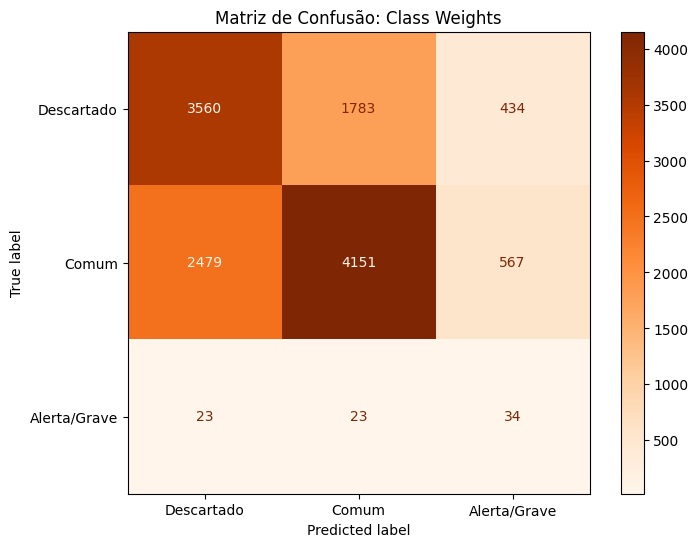

  [MLflow] 'Class Weights' — f1_macro=0.431  recall_alerta_grave=0.425


'89ea522d1f6f4c9796e4c8b069c306be'

In [41]:
# Matriz de Confusão - Class Weights
cm_cw = confusion_matrix(y_test, y_pred_cw)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cw, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Oranges', ax=ax)
plt.title('Matriz de Confusão: Class Weights')
plt.show()
log_exp('Class Weights', 'LightGBM', 'ClassWeights', y_test, y_pred_cw, fig,
    params={'random_state': RANDOM_STATE, 'class_weight': 'balanced'},
    model=model_cw)

### Experimento 2.5: Amostragem Híbrida (Over + Under Sampling)

Nesta abordagem, vamos:
1. Reduzir o volume das classes majoritárias (0 e 1) via Under-sampling.
2. Aumentar a classe minoritária (2) via Over-sampling.

Isso cria um equilíbrio sem tornar o dataset artificialmente grande demais.

--- Experimento: Híbrido (RandomUnder + RandomOver) ---
Distribuição após Amostragem Híbrida:
classificacao_agrupada
0    10000
1    10000
2    10000
Name: count, dtype: int64
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002091 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 27
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612



--- Relatório de Classificação (Híbrido) ---
              precision    recall  f1-score   support

  Descartado       0.58      0.60      0.59      5777
       Comum       0.69      0.58      0.63      7197
Alerta/Grave       0.03      0.44      0.06        80

    accuracy                           0.59     13054
   macro avg       0.44      0.54      0.43     13054
weighted avg       0.64      0.59      0.61     13054



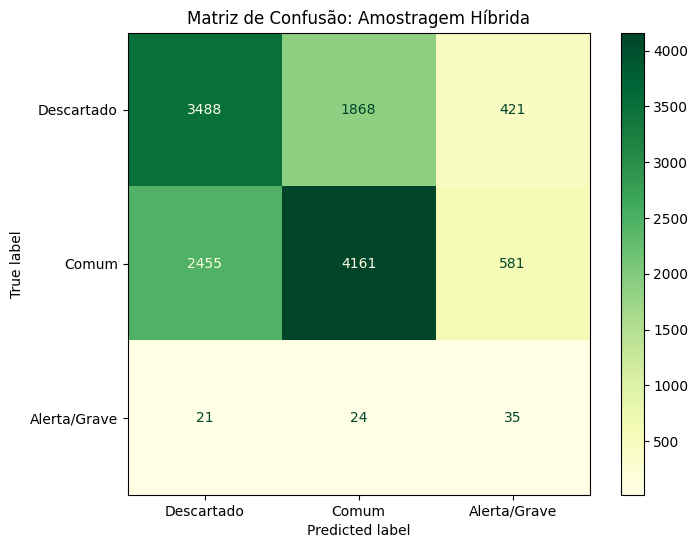

  [MLflow] 'Hybrid Sampling' — f1_macro=0.428  recall_alerta_grave=0.438


'210174f1f770438eb0a1e282f291a5f9'

In [42]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

print("--- Experimento: Híbrido (RandomUnder + RandomOver) ---")

# Definindo a estratégia:
# 1. Reduzimos 0 e 1 para um valor fixo (ex: 15000 cada)
# 2. Aumentamos a classe 2 para esse mesmo valor

under_strategy = {0: 10000, 1: 10000}
over_strategy = {2: 10000}

undersample = RandomUnderSampler(sampling_strategy=under_strategy, random_state=RANDOM_STATE)
oversample = RandomOverSampler(sampling_strategy=over_strategy, random_state=RANDOM_STATE)

# Aplicando em sequência
X_res, y_res = undersample.fit_resample(X_train, y_train)
X_res, y_res = oversample.fit_resample(X_res, y_res)

print(f"Distribuição após Amostragem Híbrida:\n{y_res.value_counts()}")

# Treinamento
model_hybrid = LGBMClassifier(objective='multiclass', num_class=3, random_state=RANDOM_STATE)
model_hybrid.fit(X_res, y_res)

# Avaliação
y_pred_hybrid = model_hybrid.predict(X_test)
print("\n--- Relatório de Classificação (Híbrido) ---")
print(classification_report(y_test, y_pred_hybrid, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

# Visualização
cm_hybrid = confusion_matrix(y_test, y_pred_hybrid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hybrid, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlGn', ax=ax)
plt.title('Matriz de Confusão: Amostragem Híbrida')
plt.show()
log_exp('Hybrid Sampling', 'LightGBM', 'Under+Over', y_test, y_pred_hybrid, fig,
    params={'random_state': RANDOM_STATE, 'under_0': 10000, 'under_1': 10000, 'over_2': 10000},
    model=model_hybrid)

### Experimento 2.8: Random Forest com Amostragem Híbrida (Under + Over)

Combinando o balanceamento de classes via sub-amostragem e super-amostragem com a robustez de um modelo Random Forest.

--- Experimento: Random Forest + Hybrid Sampling ---
Distribuição após Amostragem Híbrida:
classificacao_agrupada
0    10000
1    10000
2    10000
Name: count, dtype: int64



--- Relatório de Classificação (RF Híbrido) ---
              precision    recall  f1-score   support

  Descartado       0.55      0.61      0.58      5777
       Comum       0.66      0.61      0.63      7197
Alerta/Grave       0.04      0.04      0.04        80

    accuracy                           0.60     13054
   macro avg       0.42      0.42      0.42     13054
weighted avg       0.61      0.60      0.60     13054



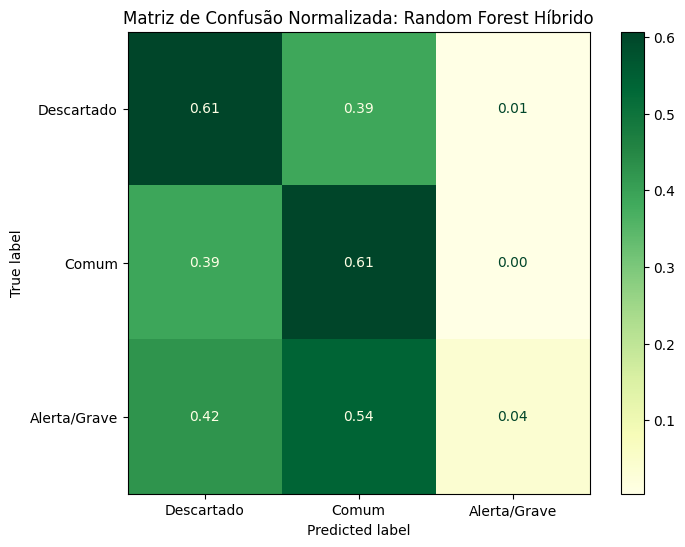

  [MLflow] 'RF Hybrid' — f1_macro=0.416  recall_alerta_grave=0.037


'7c117604b0684093948e94ac39a635b2'

In [43]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("--- Experimento: Random Forest + Hybrid Sampling ---")

# 1. Definindo a estratégia de amostragem (igual ao experimento híbrido anterior)
under_strategy = {0: 10000, 1: 10000}
over_strategy = {2: 10000}

undersample = RandomUnderSampler(sampling_strategy=under_strategy, random_state=RANDOM_STATE)
oversample = RandomOverSampler(sampling_strategy=over_strategy, random_state=RANDOM_STATE)

# 2. Aplicando a amostragem ao conjunto de treino
X_res_rf, y_res_rf = undersample.fit_resample(X_train, y_train)
X_res_rf, y_res_rf = oversample.fit_resample(X_res_rf, y_res_rf)

print(f"Distribuição após Amostragem Híbrida:\n{y_res_rf.value_counts()}")

# 3. Treinando o Random Forest
rf_hybrid_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_hybrid_model.fit(X_res_rf, y_res_rf)

# 4. Avaliação
y_pred_rf_hybrid = rf_hybrid_model.predict(X_test)

print("\n--- Relatório de Classificação (RF Híbrido) ---")
print(classification_report(y_test, y_pred_rf_hybrid, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

# 5. Visualização da Matriz de Confusão Normalizada
cm_rf_h = confusion_matrix(y_test, y_pred_rf_hybrid)
cm_rf_h_norm = cm_rf_h.astype('float') / cm_rf_h.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_h_norm, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlGn', ax=ax, values_format='.2f')
plt.title('Matriz de Confusão Normalizada: Random Forest Híbrido')
plt.show()
log_exp('RF Hybrid', 'RandomForest', 'Under+Over', y_test, y_pred_rf_hybrid, fig,
    params={'n_estimators': 100, 'random_state': RANDOM_STATE},
    model=rf_hybrid_model)

### Experimento 3: Abordagem Hierárquica (Cascata)

Nesta estratégia, dividimos o problema em dois níveis:
1. **Nível 1:** Classificador Binário (Dengue vs. Descartado).
2. **Nível 2:** Classificador de Gravidade (Comum vs. Alerta/Grave) aplicado apenas aos casos identificados como Dengue no Nível 1.

[LightGBM] [Info] Number of positive: 29105, number of negative: 23108
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 52213, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.557428 -> initscore=0.230731
[LightGBM] [Info] Start training from score 0.230731


[LightGBM] [Info] Number of positive: 321, number of negative: 28784
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 29105, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.011029 -> initscore=-4.496134
[LightGBM] [Info] Start training from score -4.496134



--- Relatório de Classificação: Modelo em Cascata ---
              precision    recall  f1-score   support

  Descartado       0.64      0.51      0.57      5777
       Comum       0.66      0.74      0.70      7197
Alerta/Grave       0.04      0.23      0.07        80

    accuracy                           0.63     13054
   macro avg       0.45      0.49      0.44     13054
weighted avg       0.65      0.63      0.64     13054



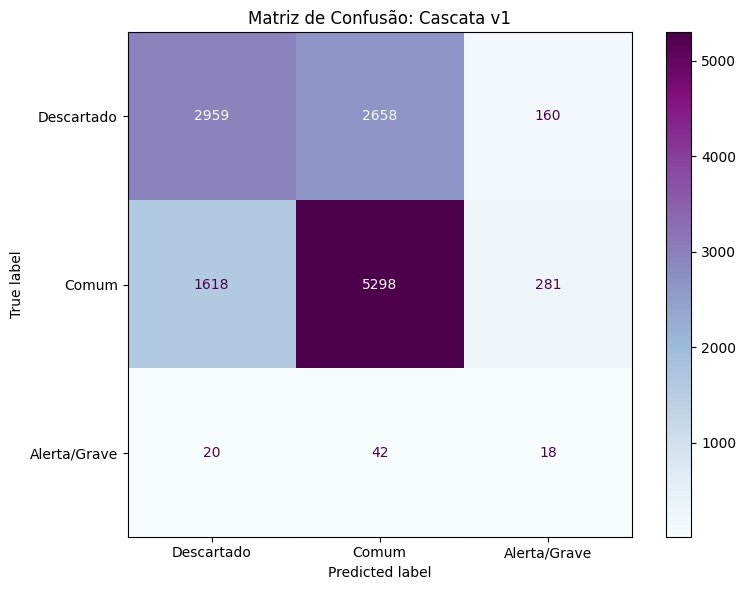

  [MLflow] 'Cascata v1' — f1_macro=0.445  recall_alerta_grave=0.225


'ff24bd276a4544ecbfc457959c39aed7'

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier

# --- PASSO 1: Preparar Alvos Binários ---
# Alvo 1: 0 = Descartado, 1 = Dengue (Comum + Grave)
y_train_dengue = (y_train > 0).astype(int)
y_test_dengue = (y_test > 0).astype(int)

# --- PASSO 2: Treinar Modelo de Detecção (Nível 1) ---
model_detect = LGBMClassifier(random_state=RANDOM_STATE)
model_detect.fit(X_train, y_train_dengue)

# --- PASSO 3: Treinar Modelo de Gravidade (Nível 2) ---
# Apenas instâncias de Dengue (1 e 2)
mask_train = y_train > 0
X_train_sev = X_train[mask_train]
y_train_sev = (y_train[mask_train] == 2).astype(int) # 0=Comum, 1=Grave

# Pesos pesados para a classe Grave no Nível 2
model_sev = LGBMClassifier(scale_pos_weight=50, random_state=RANDOM_STATE)
model_sev.fit(X_train_sev, y_train_sev)

# --- PASSO 4: Inferência em Cascata ---
# 1. Predição de ser dengue ou não
y_pred_detect = model_detect.predict(X_test)

# 2. Para os que o modelo disse ser Dengue, prever gravidade
final_preds = np.zeros_like(y_pred_detect)
indices_dengue = np.where(y_pred_detect == 1)[0]

if len(indices_dengue) > 0:
    sev_preds = model_sev.predict(X_test.iloc[indices_dengue])
    # Mapear de volta: 0(Descartado), 1(Comum), 2(Grave)
    # Se sev_preds for 0 -> 1 (Comum). Se sev_preds for 1 -> 2 (Grave).
    final_preds[indices_dengue] = np.where(sev_preds == 0, 1, 2)

# --- PASSO 5: Avaliação Final ---
print("\n--- Relatório de Classificação: Modelo em Cascata ---")
print(classification_report(y_test, final_preds, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

# Visualização e MLflow — Cascata v1
from sklearn.metrics import ConfusionMatrixDisplay
cm_cascata = confusion_matrix(y_test, final_preds)
fig_cascata, ax_cascata = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_cascata,
    display_labels=['Descartado', 'Comum', 'Alerta/Grave']).plot(cmap='BuPu', ax=ax_cascata)
ax_cascata.set_title('Matriz de Confusão: Cascata v1')
plt.tight_layout()
plt.show()
log_exp('Cascata v1', 'LightGBM', 'Cascata2Niveis', y_test, final_preds, fig_cascata,
    params={'random_state': RANDOM_STATE, 'scale_pos_weight_nivel2': 50})

### Experimento 4: Detecção de Anomalias com Isolation Forest

Dado que a classe 'Alerta/Grave' é extremamente rara, vamos testar se um modelo de detecção de anomalias consegue identificá-la isolando esses casos como outliers.

--- Experimento: Isolation Forest ---


Taxa de contaminação usada: 0.0061

--- Relatório de Classificação (Isolation Forest como Detector de Classe 2) ---
                     precision    recall  f1-score   support

   Descartado/Comum       0.00      0.00      0.00      5777
Classe 1 (Ignorada)       0.55      0.99      0.71      7197
       Alerta/Grave       0.01      0.01      0.01        80

           accuracy                           0.55     13054
          macro avg       0.19      0.33      0.24     13054
       weighted avg       0.30      0.55      0.39     13054



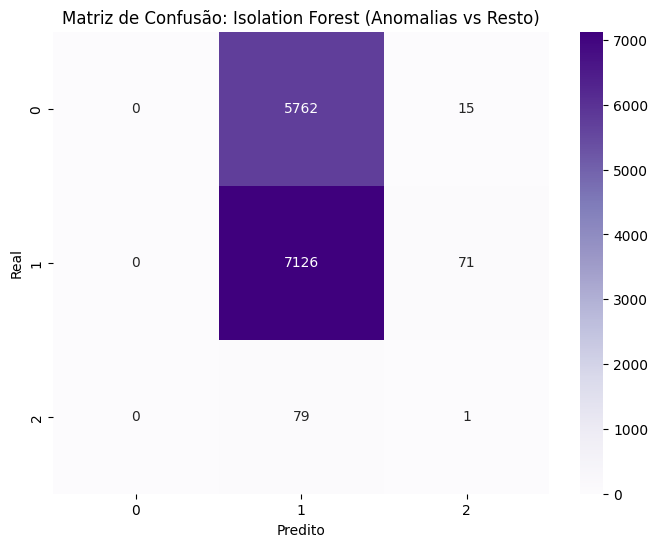

  [MLflow] 'Isolation Forest' — f1_macro=0.240  recall_alerta_grave=0.013


'9044589260034efa88859428de47f8f0'

In [45]:
from sklearn.ensemble import IsolationForest

print("--- Experimento: Isolation Forest ---")

# O Isolation Forest é não supervisionado, mas vamos treinar apenas nos casos 'normais' (Descartado e Comum)
# ou no dataset completo para ver como ele isola a classe 2.
X_train_if = X_train.copy()

# Estimamos a contaminação baseada na proporção real da classe 2 no treino
contamination_rate = (y_train == 2).mean()
if contamination_rate == 0: contamination_rate = 0.01 # Fallback

iso_forest = IsolationForest(contamination=contamination_rate, random_state=RANDOM_STATE)
iso_forest.fit(X_train_if)

# Predição: -1 para anomalia, 1 para normal
y_pred_if_raw = iso_forest.predict(X_test)

# Mapeamento para comparação:
# Vamos assumir que as 'anomalias' (-1) seriam nossa classe 2 (Alerta/Grave)
# E os 'normais' (1) seriam as outras classes.
# Nota: Esta é uma simplificação para ver o potencial de isolamento da classe 2.
y_pred_if = np.where(y_pred_if_raw == -1, 2, 1)

print(f"Taxa de contaminação usada: {contamination_rate:.4f}")
print("\n--- Relatório de Classificação (Isolation Forest como Detector de Classe 2) ---")
# Comparando apenas recall da classe 2
print(classification_report(y_test, y_pred_if, target_names=['Descartado/Comum', 'Classe 1 (Ignorada)', 'Alerta/Grave']))

# Matriz de Confusão
cm_if = confusion_matrix(y_test, y_pred_if)
fig_if = plt.figure(figsize=(8, 6))
sns.heatmap(cm_if, annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusão: Isolation Forest (Anomalias vs Resto)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()
log_exp('Isolation Forest', 'IsolationForest', 'Anomalia', y_test, y_pred_if, fig_if,
    params={'contamination': float(contamination_rate), 'random_state': RANDOM_STATE})

### Experimento 5: Feature Engineering + Class Weights

Neste experimento, criaremos novas features de interação entre sintomas e features temporais para tentar melhorar a separabilidade da classe 'Alerta/Grave'.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003337 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 489
[LightGBM] [Info] Number of data points in the train set: 52213, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612



--- Relatório de Classificação (FE + Class Weights) ---
              precision    recall  f1-score   support

  Descartado       0.59      0.62      0.61      5777
       Comum       0.70      0.59      0.64      7197
Alerta/Grave       0.03      0.35      0.05        80

    accuracy                           0.60     13054
   macro avg       0.44      0.52      0.43     13054
weighted avg       0.65      0.60      0.62     13054



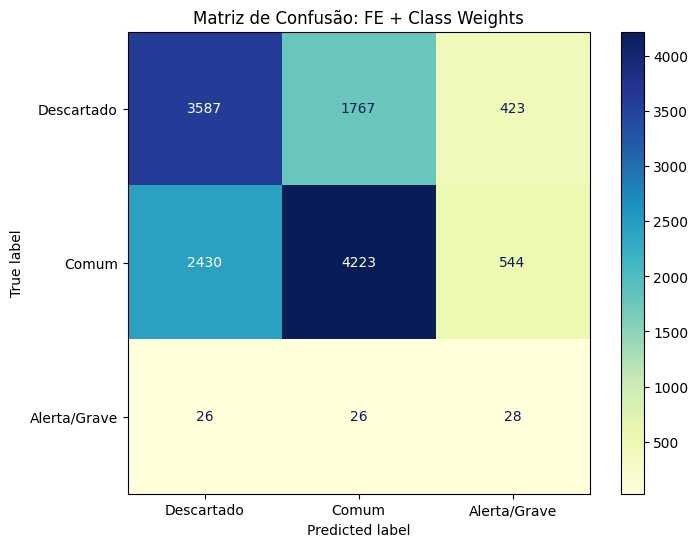

  [MLflow] 'FE + Class Weights' — f1_macro=0.433  recall_alerta_grave=0.350


'cdcc19ba53054c43b0177dae1658e4ca'

In [46]:
df_fe = df.copy()

# 1. Interação de Sintomas: Casos graves costumam apresentar múltiplos sintomas simultâneos
df_fe['soma_sintomas'] = df_fe[['febre', 'mialgia', 'cefaleia', 'exantema', 'vomito', 'nausea']].sum(axis=1)

# 2. Transformação Cíclica da Semana (para capturar sazonalidade)
df_fe['semana_sin'] = np.sin(2 * np.pi * df_fe['semana_num'] / 53)
df_fe['semana_cos'] = np.cos(2 * np.pi * df_fe['semana_num'] / 53)

# 3. Interação entre Febre e Vômito (Sinais de alerta comuns)
df_fe['febre_e_vomito'] = df_fe['febre'] * df_fe['vomito']

# Preparação dos dados
X_fe = df_fe.drop(columns=['classificacao_agrupada'])
y_fe = df_fe['classificacao_agrupada']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe
)

# Pesos de Classe
weights_fe = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_fe), y=y_train_fe)
weights_fe_dict = {i: weights_fe[i] for i in range(len(weights_fe))}

# Treinamento
model_fe = LGBMClassifier(objective='multiclass', random_state=RANDOM_STATE, class_weight=weights_fe_dict)
model_fe.fit(X_train_fe, y_train_fe)

# Avaliação
y_pred_fe = model_fe.predict(X_test_fe)
print("\n--- Relatório de Classificação (FE + Class Weights) ---")
print(classification_report(y_test_fe, y_pred_fe, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

# Matriz de Confusão
cm_fe = confusion_matrix(y_test_fe, y_pred_fe)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_fe, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlGnBu', ax=ax)
plt.title('Matriz de Confusão: FE + Class Weights')
plt.show()
log_exp('FE + Class Weights', 'LightGBM', 'FeatureEng+ClassWeights', y_test_fe, y_pred_fe, fig,
    params={'random_state': RANDOM_STATE,
            'features_extras': 'soma_sintomas,semana_sin,semana_cos,febre_e_vomito'},
    model=model_fe)

### Experimento 3: Abordagem de Dois Modelos

Neste experimento, propomos uma abordagem de dois modelos para lidar com a classificação dos casos de dengue, especialmente os 'Alerta/Grave', que são minoritários e críticos.

**Modelo 1: Detecção de Dengue (Binário)**

Este modelo tem como objetivo principal distinguir entre 'Descartado' e 'Dengue' (onde 'Dengue' agrupa 'Comum' e 'Alerta/Grave').

*   **Target:** `dengue_vs_descartado` (0 para 'Descartado', 1 para 'Dengue').
*   **Objetivo:** Reduzir falsos negativos para casos de dengue.

**Modelo 2: Classificação de Gravidade (Binário)**

Este modelo atua como um refinador, classificando apenas os casos que o Modelo 1 identificou como 'Dengue'. Ele irá distinguir entre 'Comum' e 'Alerta/Grave'.

*   **Target:** `comum_vs_alertagrave` (0 para 'Comum', 1 para 'Alerta/Grave').
*   **Objetivo:** Melhorar a precisão na identificação de casos 'Alerta/Grave' aplicando class weighting.

Vamos avaliar se essa estratégia em cascata pode melhorar o desempenho geral na detecção de casos graves.

In [47]:
# --- Preparação dos Dados para o Modelo 1 (Dengue vs. Descartado) ---
print("--- Modelo 1: Dengue (Comum + Alerta/Grave) vs. Descartado ---")

# Criar a nova coluna alvo para o Modelo 1
df_model1 = df.copy()
df_model1['dengue_vs_descartado'] = df_model1['classificacao_agrupada'].apply(lambda x: 0 if x == 0 else 1)

X_model1 = df_model1.drop(columns=['classificacao_agrupada', 'dengue_vs_descartado'])
y_model1 = df_model1['dengue_vs_descartado']

# Dividir os dados em conjuntos de treino e teste para o Modelo 1
X_train_model1, X_test_model1, y_train_model1, y_test_model1 = train_test_split(
    X_model1, y_model1, test_size=0.2, random_state=RANDOM_STATE, stratify=y_model1
)

print(f"Shape do X_train_model1: {X_train_model1.shape}")
print(f"Distribuição da classe alvo y_train_model1:\n{y_train_model1.value_counts()}")

# Treinar o Modelo 1 (LGBMClassifier)
model1 = LGBMClassifier(objective='binary', random_state=RANDOM_STATE)
model1.fit(X_train_model1, y_train_model1)

# Fazer previsões no conjunto de teste do Modelo 1
y_pred_model1 = model1.predict(X_test_model1)

# Avaliar o Modelo 1
print("\n--- Relatório de Classificação do Modelo 1 ---")
print(classification_report(y_test_model1, y_pred_model1, target_names=['Descartado', 'Dengue']))

--- Modelo 1: Dengue (Comum + Alerta/Grave) vs. Descartado ---
Shape do X_train_model1: (52213, 27)
Distribuição da classe alvo y_train_model1:
dengue_vs_descartado
1    29105
0    23108
Name: count, dtype: int64
[LightGBM] [Info] Number of positive: 29105, number of negative: 23108
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 52213, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.557428 -> initscore=0.230731
[LightGBM] [Info] Start training from score 0.230731



--- Relatório de Classificação do Modelo 1 ---
              precision    recall  f1-score   support

  Descartado       0.65      0.51      0.57      5777
      Dengue       0.67      0.78      0.72      7277

    accuracy                           0.66     13054
   macro avg       0.66      0.64      0.64     13054
weighted avg       0.66      0.66      0.65     13054



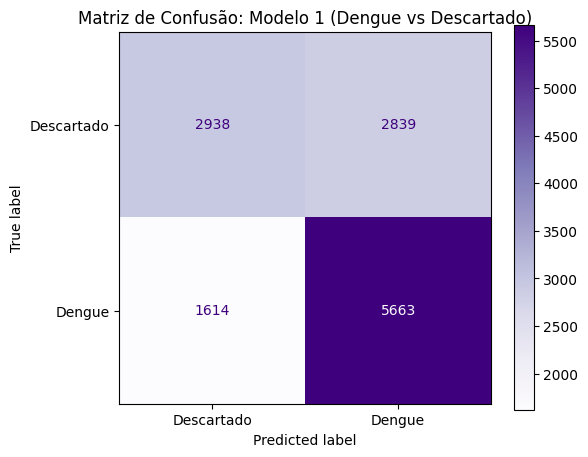

In [48]:
# Matriz de Confusão - Modelo 1 (Binário)
cm_m1 = confusion_matrix(y_test_model1, y_pred_model1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Descartado', 'Dengue'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Purples', ax=ax)
plt.title('Matriz de Confusão: Modelo 1 (Dengue vs Descartado)')
plt.show()

In [49]:
# --- Preparação dos Dados para o Modelo 2 (Comum vs. Alerta/Grave) ---
print("\n--- Modelo 2: Comum vs. Alerta/Grave (apenas casos confirmados) ---")

# Filtrar o DataFrame para incluir apenas casos 'Comum' (1) e 'Alerta/Grave' (2)
df_model2 = df[df['classificacao_agrupada'].isin([1, 2])].copy()

# Criar a nova coluna alvo para o Modelo 2 (re-mapeando para 0 e 1)
df_model2['comum_vs_alertagrave'] = df_model2['classificacao_agrupada'].apply(lambda x: 0 if x == 1 else 1)

X_model2 = df_model2.drop(columns=['classificacao_agrupada', 'comum_vs_alertagrave'])
y_model2 = df_model2['comum_vs_alertagrave']

# Dividir os dados em conjuntos de treino e teste para o Modelo 2
X_train_model2, X_test_model2, y_train_model2, y_test_model2 = train_test_split(
    X_model2, y_model2, test_size=0.2, random_state=RANDOM_STATE, stratify=y_model2
)

print(f"Shape do X_train_model2: {X_train_model2.shape}")
print(f"Distribuição da classe alvo y_train_model2:\n{y_train_model2.value_counts()}")

# Calcular os pesos de classe para o Modelo 2
class_weights_model2 = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train_model2),
    y=y_train_model2
)
class_weights_dict_model2 = {i: class_weights_model2[i] for i in range(len(class_weights_model2))}

print(f"Pesos de Classe Calculados para o Modelo 2: {class_weights_dict_model2}")

# Treinar o Modelo 2 (LGBMClassifier com class_weight)
model2 = LGBMClassifier(objective='binary', random_state=RANDOM_STATE, class_weight=class_weights_dict_model2)
model2.fit(X_train_model2, y_train_model2)

# Fazer previsões no conjunto de teste do Modelo 2
y_pred_model2 = model2.predict(X_test_model2)

# Avaliar o Modelo 2
print("\n--- Relatório de Classificação do Modelo 2 ---")
print(classification_report(y_test_model2, y_pred_model2, target_names=['Comum', 'Alerta/Grave']))


--- Modelo 2: Comum vs. Alerta/Grave (apenas casos confirmados) ---
Shape do X_train_model2: (29105, 27)
Distribuição da classe alvo y_train_model2:
comum_vs_alertagrave
0    28784
1      321
Name: count, dtype: int64
Pesos de Classe Calculados para o Modelo 2: {0: np.float64(0.5055760144524736), 1: np.float64(45.334890965732086)}
[LightGBM] [Info] Number of positive: 321, number of negative: 28784
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002042 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 29105, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000



--- Relatório de Classificação do Modelo 2 ---
              precision    recall  f1-score   support

       Comum       0.99      0.92      0.95      7197
Alerta/Grave       0.04      0.31      0.07        80

    accuracy                           0.91      7277
   macro avg       0.52      0.62      0.51      7277
weighted avg       0.98      0.91      0.94      7277



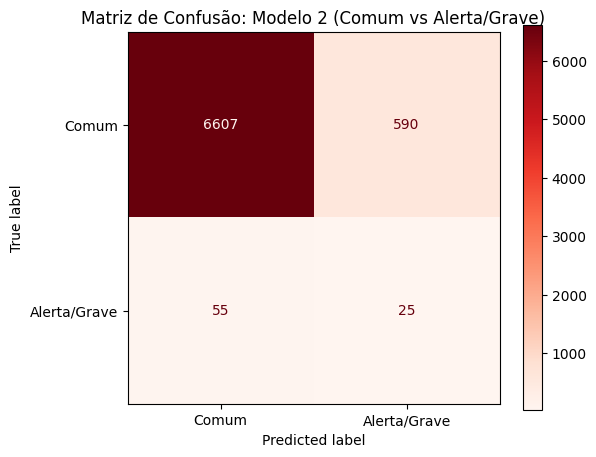

In [50]:
# Matriz de Confusão - Modelo 2 (Binário de Gravidade)
cm_m2 = confusion_matrix(y_test_model2, y_pred_model2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Comum', 'Alerta/Grave'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Reds', ax=ax)
plt.title('Matriz de Confusão: Modelo 2 (Comum vs Alerta/Grave)')
plt.show()

In [51]:
# --- Implementação da Abordagem de Dois Modelos em Sequência ---
print("\n--- Avaliação da Abordagem de Dois Modelos em Sequência ---")

# 1. Obter previsões do Modelo 1 para o X_test_model1
# Lembre-se que X_test_model1 corresponde ao X_test original, apenas renomeado para o contexto do modelo 1
y_pred_model1_full = model1.predict(X_test_model1)

# 2. Inicializar a array de previsões finais com os resultados do Modelo 1
# '0' para Descartado, '1' para Dengue (Comum ou Alerta/Grave)
y_pred_final = np.array(y_pred_model1_full)

# 3. Identificar os índices no conjunto de teste onde o Modelo 1 previu 'Dengue' (classe 1)
indices_dengue = np.where(y_pred_model1_full == 1)[0]

# 4. Extrair as features para esses casos de 'Dengue' para o Modelo 2
# Certifique-se de usar X_test_model1 com os índices corretos
X_dengue_for_model2 = X_test_model1.iloc[indices_dengue]

# 5. Obter previsões do Modelo 2 para esses casos de 'Dengue'
# O Modelo 2 prevê '0' para Comum e '1' para Alerta/Grave
y_pred_model2_dengue = model2.predict(X_dengue_for_model2)

# 6. Mapear as previsões do Modelo 2 para as classes originais (1 para Comum, 2 para Alerta/Grave)
# E atualizar as previsões finais apenas para os casos que foram classificados como Dengue pelo Modelo 1
# Se y_pred_model2_dengue for 0 (Comum), mantém 1 na previsão final
# Se y_pred_model2_dengue for 1 (Alerta/Grave), muda para 2 na previsão final
y_pred_final[indices_dengue] = y_pred_model2_dengue + 1 # Adiciona 1 para mapear 0->1 (Comum) e 1->2 (Alerta/Grave)

# 7. Avaliar a performance combinada dos dois modelos
print("\n--- Relatório de Classificação da Abordagem Hierárquica ---")
print(classification_report(y_test, y_pred_final, target_names=['Descartado', 'Comum', 'Alerta/Grave']))



--- Avaliação da Abordagem de Dois Modelos em Sequência ---

--- Relatório de Classificação da Abordagem Hierárquica ---
              precision    recall  f1-score   support

  Descartado       0.45      0.35      0.39      5777
       Comum       0.56      0.59      0.57      7197
Alerta/Grave       0.00      0.05      0.01        80

    accuracy                           0.48     13054
   macro avg       0.34      0.33      0.33     13054
weighted avg       0.50      0.48      0.49     13054



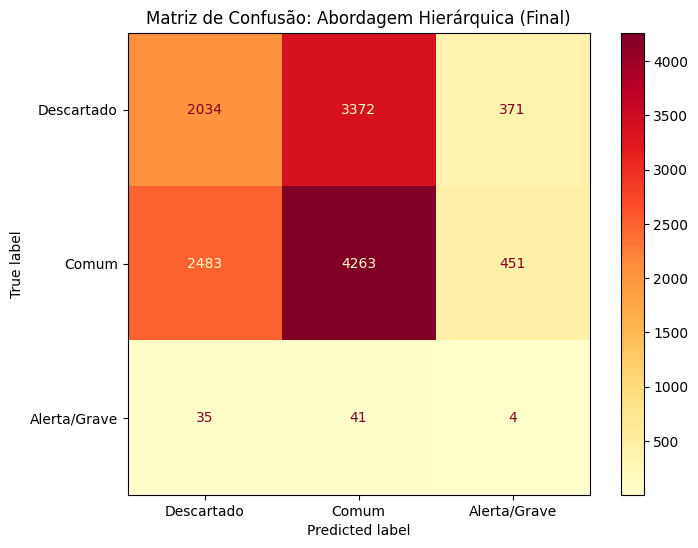

  [MLflow] 'Hierarquica' — f1_macro=0.325  recall_alerta_grave=0.050


'e7013635120645d2a4e2c105c895a34c'

In [52]:
# Matriz de Confusão - Abordagem Hierárquica Final
cm_hierarquica = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_hierarquica, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlOrRd', ax=ax)
plt.title('Matriz de Confusão: Abordagem Hierárquica (Final)')
plt.show()
log_exp('Hierarquica', 'LightGBM', 'Cascata2Modelos', y_test, y_pred_final, fig,
    params={'random_state': RANDOM_STATE, 'class_weight_model2': 'balanced'})

### Comparativo: Matrizes de Confusão Normalizadas

Para facilitar a visualização do desempenho em classes desbalanceadas, vamos plotar as matrizes de todos os experimentos anteriores normalizadas pelo número de instâncias reais de cada classe.

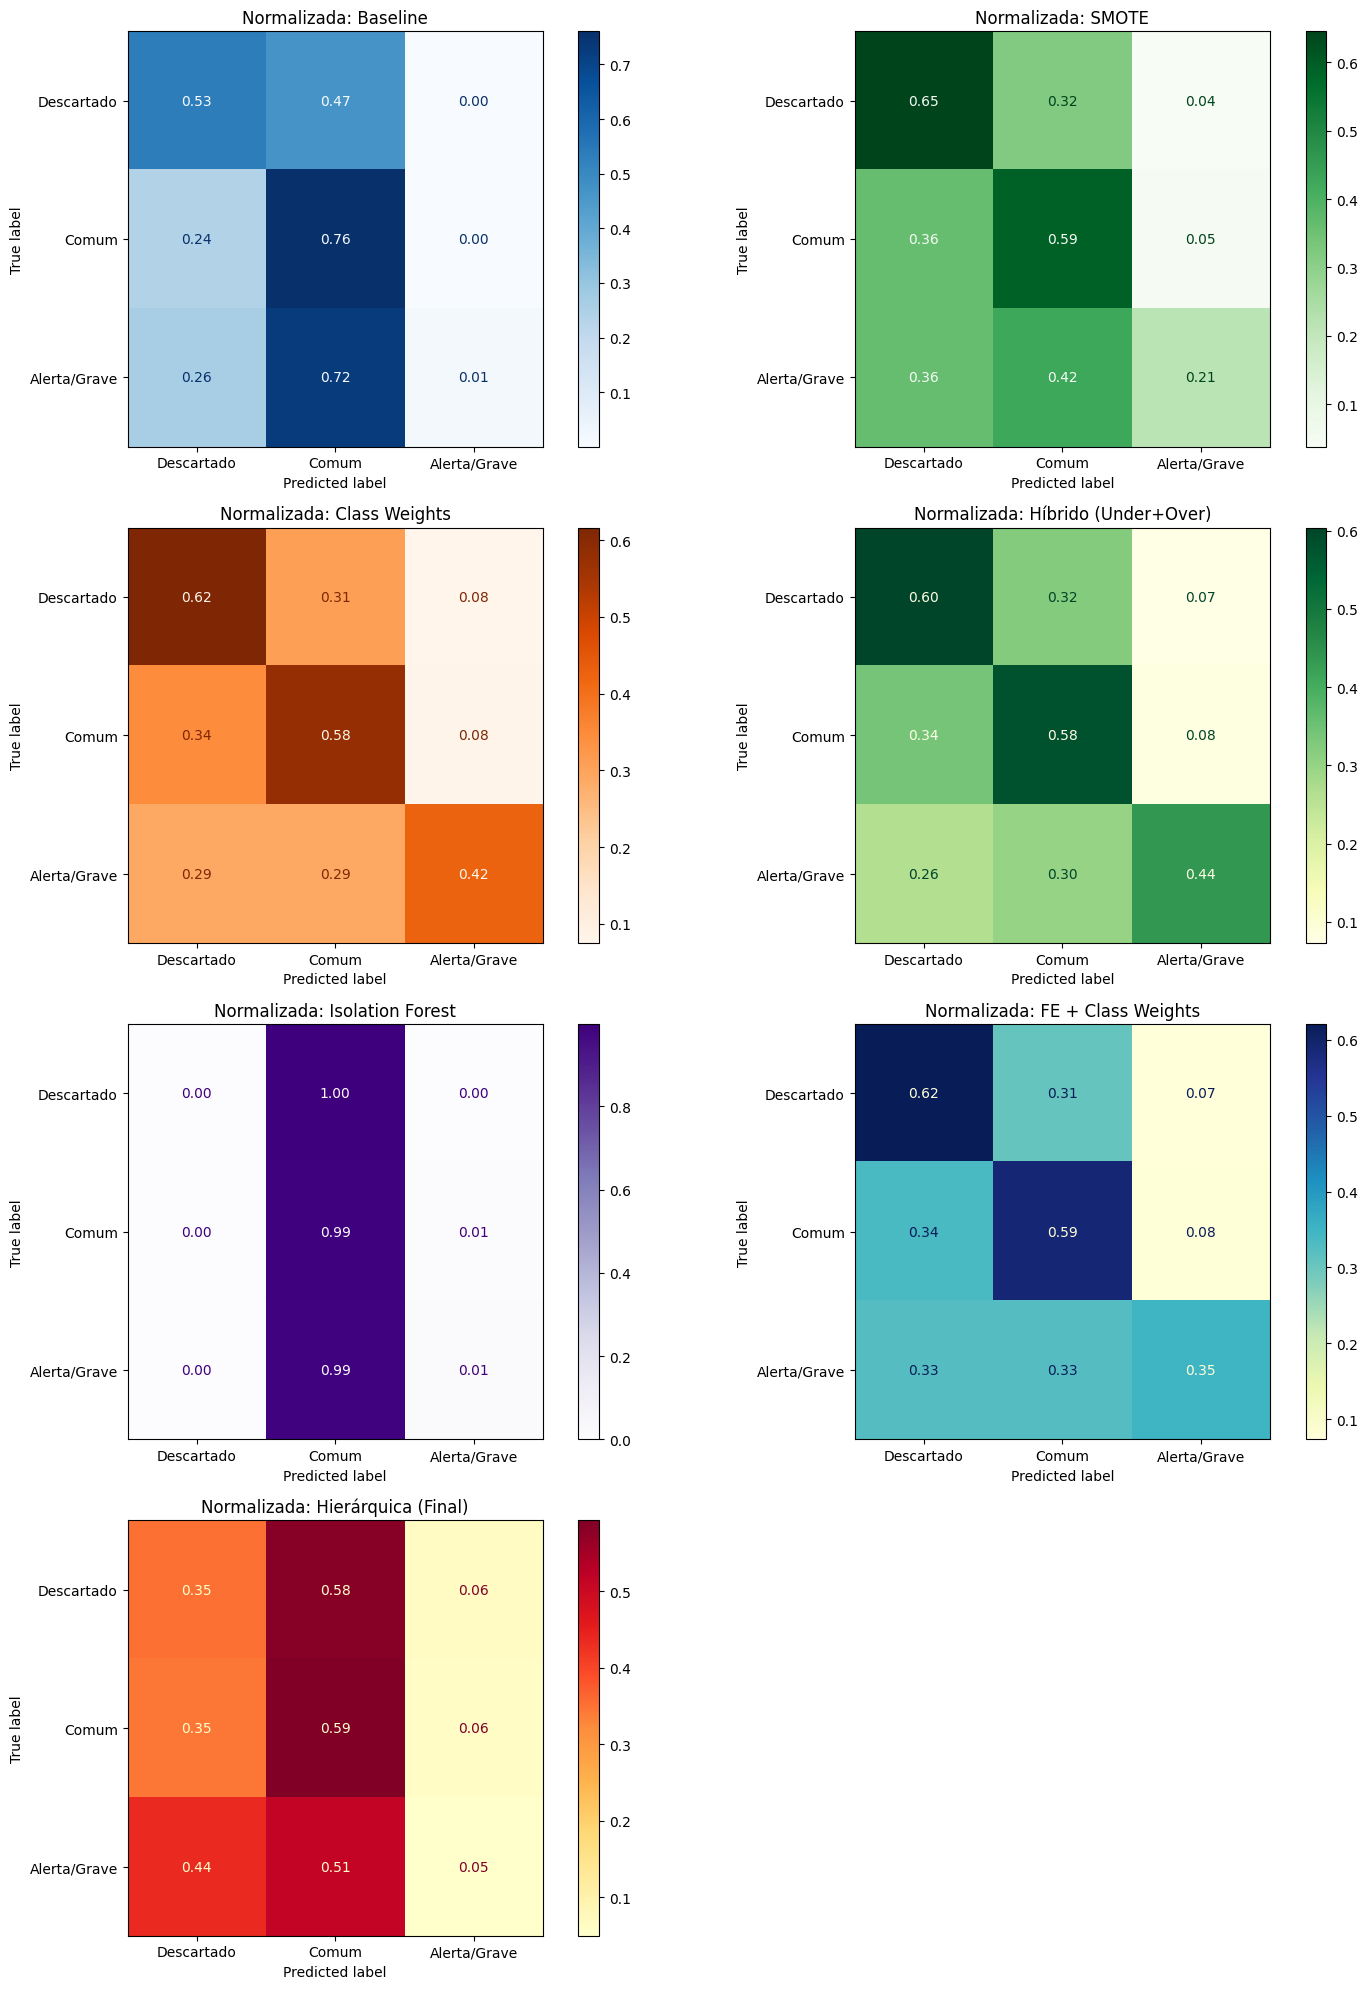

In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Lista de matrizes e títulos coletados dos experimentos anteriores
# Note: as variáveis cm_... devem existir no kernel
experimentos = [
    (cm_baseline, 'Baseline', 'Blues'),
    (cm_smote, 'SMOTE', 'Greens'),
    (cm_cw, 'Class Weights', 'Oranges'),
    (cm_hybrid, 'Híbrido (Under+Over)', 'YlGn'),
    (cm_if, 'Isolation Forest', 'Purples'),
    (cm_fe, 'FE + Class Weights', 'YlGnBu'),
    (cm_hierarquica, 'Hierárquica (Final)', 'YlOrRd')
]

# Configuração da grade de plots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

labels = ['Descartado', 'Comum', 'Alerta/Grave']

for i, (cm, titulo, cmap) in enumerate(experimentos):
    # Normalização por linha (True Class)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
    disp.plot(cmap=cmap, ax=axes[i], values_format='.2f')
    axes[i].set_title(f'Normalizada: {titulo}')

# Remover o último subplot vazio
if len(axes) > len(experimentos):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Experimento 6: XGBoost com scale_pos_weight

Neste experimento, utilizaremos o algoritmo XGBoost. Para lidar com o desbalanceamento, calcularemos o peso para a classe minoritária e o passaremos através do parâmetro `scale_pos_weight`. Note que, para problemas multiclasse no XGBoost, o ajuste de pesos por classe funciona de forma ligeiramente diferente do LightGBM (usando `sample_weight`), então usaremos uma abordagem de mapeamento de pesos por amostra.

--- Experimento: XGBoost + Sample Weights ---



--- Relatório de Classificação (XGBoost) ---
              precision    recall  f1-score   support

  Descartado       0.59      0.61      0.60      5777
       Comum       0.70      0.56      0.62      7197
Alerta/Grave       0.03      0.46      0.05        80

    accuracy                           0.58     13054
   macro avg       0.44      0.54      0.42     13054
weighted avg       0.65      0.58      0.61     13054



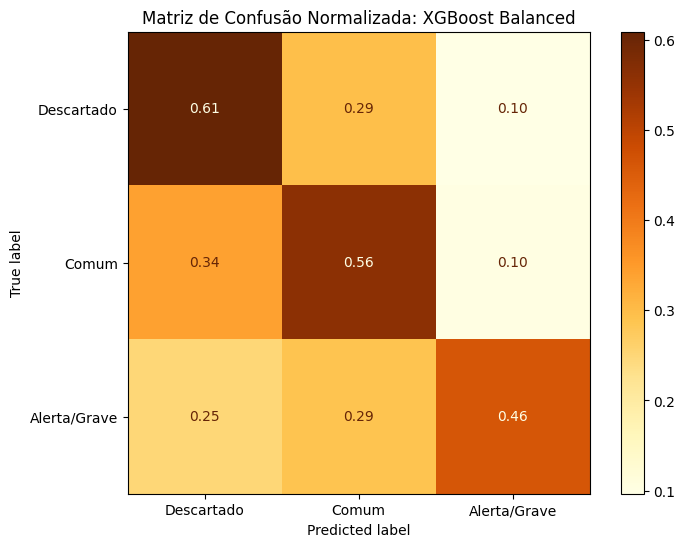

  [MLflow] 'XGBoost SampleWeights' — f1_macro=0.424  recall_alerta_grave=0.463


'06496811baed4408a7532b78c5d4bb57'

In [54]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

print("--- Experimento: XGBoost + Sample Weights ---")

# 1. Calcular pesos das amostras para o treino
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Inicializar e treinar o XGBoost
# 'multi:softprob' é o padrão para multiclasse
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    learning_rate=0.1,
    n_estimators=100
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

# 3. Predição
y_pred_xgb = xgb_model.predict(X_test)

# 4. Avaliação
print("\n--- Relatório de Classificação (XGBoost) ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

# 5. Visualização da Matriz de Confusão
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_xgb_norm = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_norm, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlOrBr', ax=ax, values_format='.2f')
plt.title('Matriz de Confusão Normalizada: XGBoost Balanced')
plt.show()
log_exp('XGBoost SampleWeights', 'XGBoost', 'SampleWeights', y_test, y_pred_xgb, fig,
    params={'learning_rate': 0.1, 'n_estimators': 100, 'random_state': RANDOM_STATE},
    model=xgb_model)

### Experimento 7: XGBoost com Amostragem Híbrida (Sem Pesos de Classe)

Nesta abordagem, removemos o ajuste de pesos interno do modelo e focamos em equilibrar o dataset manualmente através de uma combinação de sub-amostragem das classes majoritárias e super-amostragem da classe minoritária.

--- Experimento: XGBoost + Hybrid Sampling (No Weights) ---
Distribuição após reamostragem:
classificacao_agrupada
0    10000
1    10000
2    10000
Name: count, dtype: int64



--- Relatório de Classificação (XGBoost Híbrido) ---
              precision    recall  f1-score   support

  Descartado       0.58      0.60      0.59      5777
       Comum       0.69      0.56      0.62      7197
Alerta/Grave       0.03      0.45      0.05        80

    accuracy                           0.58     13054
   macro avg       0.44      0.54      0.42     13054
weighted avg       0.64      0.58      0.60     13054



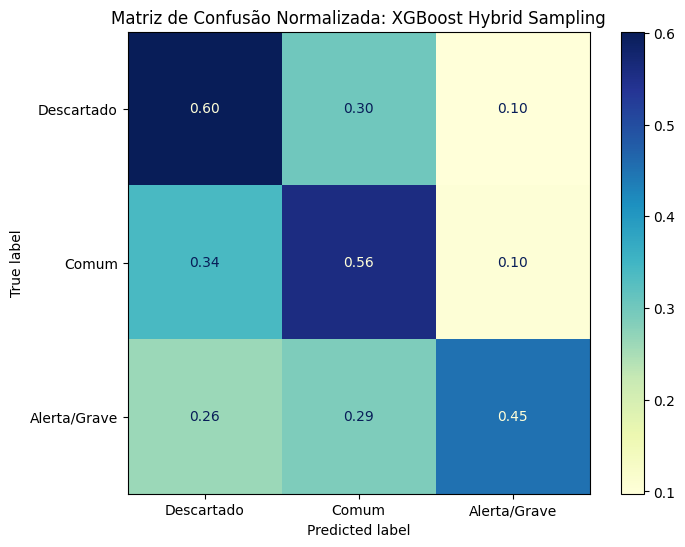

  [MLflow] 'XGBoost Hybrid' — f1_macro=0.420  recall_alerta_grave=0.450


'2c2c35f4b0db4a4f9d2218fa43b64920'

In [55]:
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

print("--- Experimento: XGBoost + Hybrid Sampling (No Weights) ---")

# 1. Definir estratégia de amostragem híbrida
# Reduzimos 0 e 1 para 10.000 amostras cada
# Aumentamos a classe 2 para 10.000 amostras
under_strategy = {0: 10000, 1: 10000}
over_strategy = {2: 10000}

undersample = RandomUnderSampler(sampling_strategy=under_strategy, random_state=RANDOM_STATE)
oversample = RandomOverSampler(sampling_strategy=over_strategy, random_state=RANDOM_STATE)

# 2. Aplicar amostragem ao treino
X_train_res, y_train_res = undersample.fit_resample(X_train, y_train)
X_train_res, y_train_res = oversample.fit_resample(X_train_res, y_train_res)

print(f"Distribuição após reamostragem:\n{y_train_res.value_counts()}")

# 3. Treinar XGBoost sem pesos de classe (modelo padrão)
xgb_hybrid = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    learning_rate=0.1,
    n_estimators=100
)

xgb_hybrid.fit(X_train_res, y_train_res)

# 4. Predição e Avaliação
y_pred_xgb_h = xgb_hybrid.predict(X_test)

print("\n--- Relatório de Classificação (XGBoost Híbrido) ---")
print(classification_report(y_test, y_pred_xgb_h, target_names=['Descartado', 'Comum', 'Alerta/Grave']))

# 5. Visualização
cm_xgb_h = confusion_matrix(y_test, y_pred_xgb_h)
cm_xgb_h_norm = cm_xgb_h.astype('float') / cm_xgb_h.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_h_norm, display_labels=['Descartado', 'Comum', 'Alerta/Grave'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlGnBu', ax=ax, values_format='.2f')
plt.title('Matriz de Confusão Normalizada: XGBoost Hybrid Sampling')
plt.show()
log_exp('XGBoost Hybrid', 'XGBoost', 'Under+Over', y_test, y_pred_xgb_h, fig,
    params={'learning_rate': 0.1, 'n_estimators': 100, 'random_state': RANDOM_STATE,
            'under_0': 10000, 'under_1': 10000, 'over_2': 10000},
    model=xgb_hybrid)

# MLflow — Comparativo Final e Model Registry

In [56]:
# Comparativo de todos os experimentos e registro do campeão

if mlflow.active_run():
    mlflow.end_run()

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

if runs.empty:
    print("Nenhuma run encontrada. Execute os experimentos acima primeiro.")
else:
    cols_show = [
        "tags.mlflow.runName", "tags.algoritmo", "tags.balanceamento",
        "metrics.f1_macro", "metrics.recall_alerta_grave",
        "metrics.f1_alerta_grave", "metrics.accuracy"
    ]
    cols_show = [c for c in cols_show if c in runs.columns]
    resumo = runs[cols_show].rename(columns=lambda c: c.split(".")[-1])
    resumo = resumo.sort_values("f1_macro", ascending=False).reset_index(drop=True)
    display(resumo)

    # Campeão: melhor recall na classe Alerta/Grave (mais importante clinicamente)
    col_recall = "metrics.recall_alerta_grave"
    melhor = runs.dropna(subset=[col_recall]).sort_values(col_recall, ascending=False).iloc[0]
    melhor_nome = melhor.get("tags.mlflow.runName", "—")

    print(f"\nCampeão (recall Alerta/Grave): '{melhor_nome}'")
    print(f"  recall_alerta_grave = {melhor[col_recall]:.3f}")
    print(f"  f1_macro            = {melhor.get('metrics.f1_macro', 0):.3f}")

    # Model Registry
    MODEL_NAME = "triagem-dengue-champion"
    try:
        mv = mlflow.register_model(f"runs:/{melhor['run_id']}/model", MODEL_NAME)
        client = MlflowClient()
        client.set_registered_model_alias(MODEL_NAME, "champion", mv.version)
        print(f"\nModelo registrado: '{MODEL_NAME}' v{mv.version} @champion")
        print(f"Carregar em produção: mlflow.sklearn.load_model('models:/{MODEL_NAME}@champion')")
    except Exception as e:
        print(f"\nAviso: não foi possível registrar o modelo — {e}")
        print("Verifique se o experimento campeão passou model=... para log_exp().")


,runName,algoritmo,balanceamento,f1_macro,recall_alerta_grave,f1_alerta_grave,accuracy
0,Cascata v1,LightGBM,Cascata2Niveis,0.444863,0.2250,0.066790,0.633905
1,Baseline,LightGBM,Nenhum,0.437874,0.0125,0.021978,0.655508
2,SMOTE,LightGBM,SMOTE,0.434928,0.2125,0.052147,0.612533
3,FE + Class Weights,LightGBM,FeatureEng+ClassWeights,0.432750,0.3500,0.052093,0.600429
4,Class Weights,LightGBM,ClassWeights,0.431176,0.4250,0.060987,0.593305
5,Hybrid Sampling,LightGBM,Under+Over,0.428300,0.4375,0.062668,0.588632
6,XGBoost SampleWeights,XGBoost,SampleWeights,0.424314,0.4625,0.052594,0.580665
7,XGBoost Hybrid,XGBoost,Under+Over,0.420376,0.4500,0.050883,0.575686
8,RF Hybrid,RandomForest,Under+Over,0.416277,0.0375,0.040541,0.602651
9,Hierarquica,LightGBM,Cascata2Modelos,0.325309,0.0500,0.008830,0.482687



Campeão (recall Alerta/Grave): 'XGBoost SampleWeights'
  recall_alerta_grave = 0.463
  f1_macro            = 0.424

Modelo registrado: 'triagem-dengue-champion' v1 @champion
Carregar em produção: mlflow.sklearn.load_model('models:/triagem-dengue-champion@champion')


Successfully registered model 'triagem-dengue-champion'.
Created version '1' of model 'triagem-dengue-champion'.
